# .mat → per-bout CSVs + aggregated summary (no EMG)

Compressed Step1 + Step4 pipeline for .mat trials only. Extracts WBF, WBA, and opto-stim around each detected stimulus using a **fixed window** (5 s pre + `STIM_DURATION_S` during + 5 s post), saves per-bout CSVs, then aggregates across all bouts into a single summary CSV + SVG.

EMG / spike processing is skipped entirely.

---

# .mat → 按片段 CSV + 汇总（无 EMG）

这是仅针对 .mat 试次的、把第一步 + 第四步压缩在一起的精简流程。它用一个**固定时间窗**（刺激前 5 秒 + `STIM_DURATION_S` 的刺激期 + 刺激后 5 秒）提取每个检测到的刺激周围的 WBF、WBA 与光遗传刺激，保存按片段的 CSV，然后跨所有片段汇总为一个汇总 CSV + SVG。

完全跳过 EMG／锋电位处理。

**Cell 1 — Configuration & imports.** Imports the no-EMG subset of helper functions, sets `INPUT_DIR` / `OUTPUT_DIR` and `STIM_DURATION_S`, defines the fixed extraction window (`PRE = 5 s`, `POST = STIM_DURATION_S + 5 s`) and the canonical time axis every bout is resampled to, applies the Affinity-safe plot style, and defines `get_stim_color`.

**Cell 1 —— 配置与导入。** 导入无 EMG 所需的辅助函数子集，设置 `INPUT_DIR` / `OUTPUT_DIR` 与 `STIM_DURATION_S`，定义固定提取窗（`PRE = 5 秒`、`POST = STIM_DURATION_S + 5 秒`）以及每个片段重采样到的标准时间轴，应用 Affinity 友好的绘图样式，并定义 `get_stim_color`。

In [34]:
# ===== Cell 1: Configuration + imports =====
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate

from spiracle_helper_functions import (
    load_and_reshape_data,
    extract_traces,
    smooth_data,
    transform_opto_stimulus,
    detect_stim_onsets,
    load_stim_orders,
    match_stim_times,
    extract_bout,
    save_bout_to_csv,
    calculate_mean_and_sem,
    set_plot_style,
)

# -------- EDIT ME --------
INPUT_DIR = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/3_SpMN/SpMN4_ChR_10s_noPhantom'
OUTPUT_DIR = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/3_SpMN/SpMN4_ChR_10s_noPhantom'
STIM_DURATION_S = 10   # seconds, the "during" window applied uniformly to every bout
# --------------------------

FS = 20000
PRE = 5.0
POST = STIM_DURATION_S + 5.0   # extract_bout's post_stim_time is measured from ONSET
BOUT_LEN = int((PRE + POST) * FS)
CANONICAL_T = np.linspace(-PRE, POST, BOUT_LEN, endpoint=False)

BOUTS_DIR = os.path.join(OUTPUT_DIR, "per_bout_csvs")
os.makedirs(BOUTS_DIR, exist_ok=True)

set_plot_style()   # Arial + editable-text SVG, 300 dpi

def get_stim_color(path):
    if 'ChR' in path:
        return 'crimson'
    if 'GtACR' in path:
        return 'lightgreen'
    return 'lightgray'

print(f"INPUT_DIR  = {INPUT_DIR}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")
print(f"STIM_DURATION_S = {STIM_DURATION_S} s  -> bout length {BOUT_LEN} samples ({(PRE+POST):.2f} s)")


INPUT_DIR  = /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/3_SpMN/SpMN4_ChR_10s_noPhantom
OUTPUT_DIR = /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/3_SpMN/SpMN4_ChR_10s_noPhantom
STIM_DURATION_S = 10 s  -> bout length 400000 samples (20.00 s)


**Cell 2 — Batch `.mat` → per-bout CSVs.** For each `.mat`: load it, extract WBF / WBA / opto (EMG ignored), smooth WBF/WBA, binarize the opto signal, detect stimulus onsets, match them to the planned stimulus order, and extract a fixed-window bout around each delivered stimulus. The opto trace is overwritten with a clean synthetic template, and each bout is saved as a CSV (bouts whose window exceeds the trial bounds, or 0 ms 'planned-but-not-delivered' stimuli, are skipped).

**Cell 2 —— 批量 `.mat` → 按片段 CSV。** 对每个 `.mat`：载入，提取 WBF / WBA / 光遗传（忽略 EMG），对 WBF/WBA 平滑，将光遗传信号二值化，检测刺激起始，并与预设刺激顺序匹配，然后围绕每次实际给出的刺激提取一个固定窗片段。光遗传曲线被替换为干净的合成模板，每个片段保存为 CSV（窗口超出试次边界的片段，或 0 ms“计划但未实际给出”的刺激，将被跳过）。

In [35]:
# ===== Cell 2: Batch process .mat files into per-bout CSVs =====
mat_files = sorted(glob.glob(os.path.join(INPUT_DIR, "*.mat")))
print(f"Found {len(mat_files)} .mat files in {INPUT_DIR}")

synthetic_stim_template = np.zeros(BOUT_LEN)
synthetic_stim_template[int(PRE * FS):int((PRE + STIM_DURATION_S) * FS)] = 1

saved_total = 0
for fp in mat_files:
    prefix = os.path.splitext(os.path.basename(fp))[0]
    print(f"\n--- Processing: {prefix} ---")
    try:
        data = load_and_reshape_data(fp)
        wbf_raw, _spike_ignored, opto_raw, wba_raw, x_pos, hutch = extract_traces(data)

        wbf = smooth_data(wbf_raw) * 100
        wba = smooth_data(wba_raw)
        opto_bin = transform_opto_stimulus(opto_raw, FS)
        time_s = np.arange(len(wbf)) / FS
        trial_dur_s = len(wbf) / FS

        data_dict = {
            'Time (s)': time_s,
            'Wingbeat Frequency': wbf,
            'Wing Beat Amplitude': wba,
            'X Position': x_pos,
            'Opto Stimulus': opto_bin,
            'hutchens': hutch,
        }

        onsets = detect_stim_onsets(opto_bin, FS)
        orders = load_stim_orders(fp)
        if orders is not None:
            stim_times = match_stim_times(onsets, orders)
        else:
            print("  Warning: no 'allRandomizedStimOrders' found; falling back to detected onsets.")
            stim_times = [(float(t), None) for t in onsets]

        for i, (onset, duration_ms) in enumerate(stim_times, 1):
            if duration_ms == 0:
                continue   # planned but never delivered

            if onset - PRE < 0 or onset + POST > trial_dur_s:
                print(f"  Skipping bout {i} (onset={onset:.2f}s): window exceeds trial bounds [0, {trial_dur_s:.2f}]")
                continue

            duration_s_for_bout = (duration_ms or 0) / 1000.0
            bout = extract_bout(
                data_dict, onset, duration_s_for_bout,
                pre_stim_time=PRE, post_stim_time=POST, sampling_rate=FS,
            )

            n = len(bout['Time (s)'])
            if n != BOUT_LEN:
                print(f"  Skipping bout {i}: length {n} != expected {BOUT_LEN}")
                continue

            bout['Opto Stimulus'] = synthetic_stim_template.copy()

            if duration_ms is not None and duration_ms > 0:
                out_path = save_bout_to_csv(bout, BOUTS_DIR, prefix, i)
            else:
                out_path = os.path.join(BOUTS_DIR, f"{prefix}_bout{i}_stimUnknownms.csv")
                pd.DataFrame(bout).to_csv(out_path, index=False)
            saved_total += 1
            print(f"  Saved bout {i} (onset={onset:.2f}s, dur={duration_ms}ms) -> {os.path.basename(out_path)}")
    except Exception as e:
        print(f"  ERROR processing {prefix}: {e}")
        continue

print(f"\nTotal bouts saved: {saved_total}")


Found 8 .mat files in /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/3_SpMN/SpMN4_ChR_10s_noPhantom

--- Processing: SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly3_Trial6_10000ms_66_thorax_2025_1226_162645 ---
Loaded data shape: (9, 5395000)
Number of blocks detected: 3
Lengths of detected blocks (in seconds): [10.0, 9.9969, 9.9969]
Loaded stimulus orders: [[np.uint16(10000)], [np.uint16(10000)], [np.uint16(10000)]]
  Saved bout 1 (onset=45.00s, dur=10000ms) -> SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly3_Trial6_10000ms_66_thorax_2025_1226_162645_bout1_stim10000ms.csv
  Saved bout 2 (onset=134.95s, dur=10000ms) -> SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly3_Trial6_10000ms_66_thorax_2025_1226_162645_bout2_stim10000ms.csv
  Saved bout 3 (onset=224.85s, dur=10000ms) -> SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly3_Trial6_10000ms_66_thorax_2025_1226_162645_bout3_stim10000ms.csv

--

**Cell 2b — Per-bout SVG plots.** For each per-bout CSV, draws a dual-axis figure (WBF on the left, Normalized WBA as Δ% on the right) with the stimulus window shaded, saved into `OUTPUT_DIR/per_bout_plots/`.

**Cell 2b —— 单片段 SVG 绘图。** 为每个按片段 CSV 绘制双轴图（左轴 WBF，右轴以 Δ% 表示的归一化 WBA），并对刺激窗加阴影，保存到 `OUTPUT_DIR/per_bout_plots/`。

Plotting 22 individual bouts -> /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/3_SpMN/SpMN4_ChR_10s_noPhantom/per_bout_plots


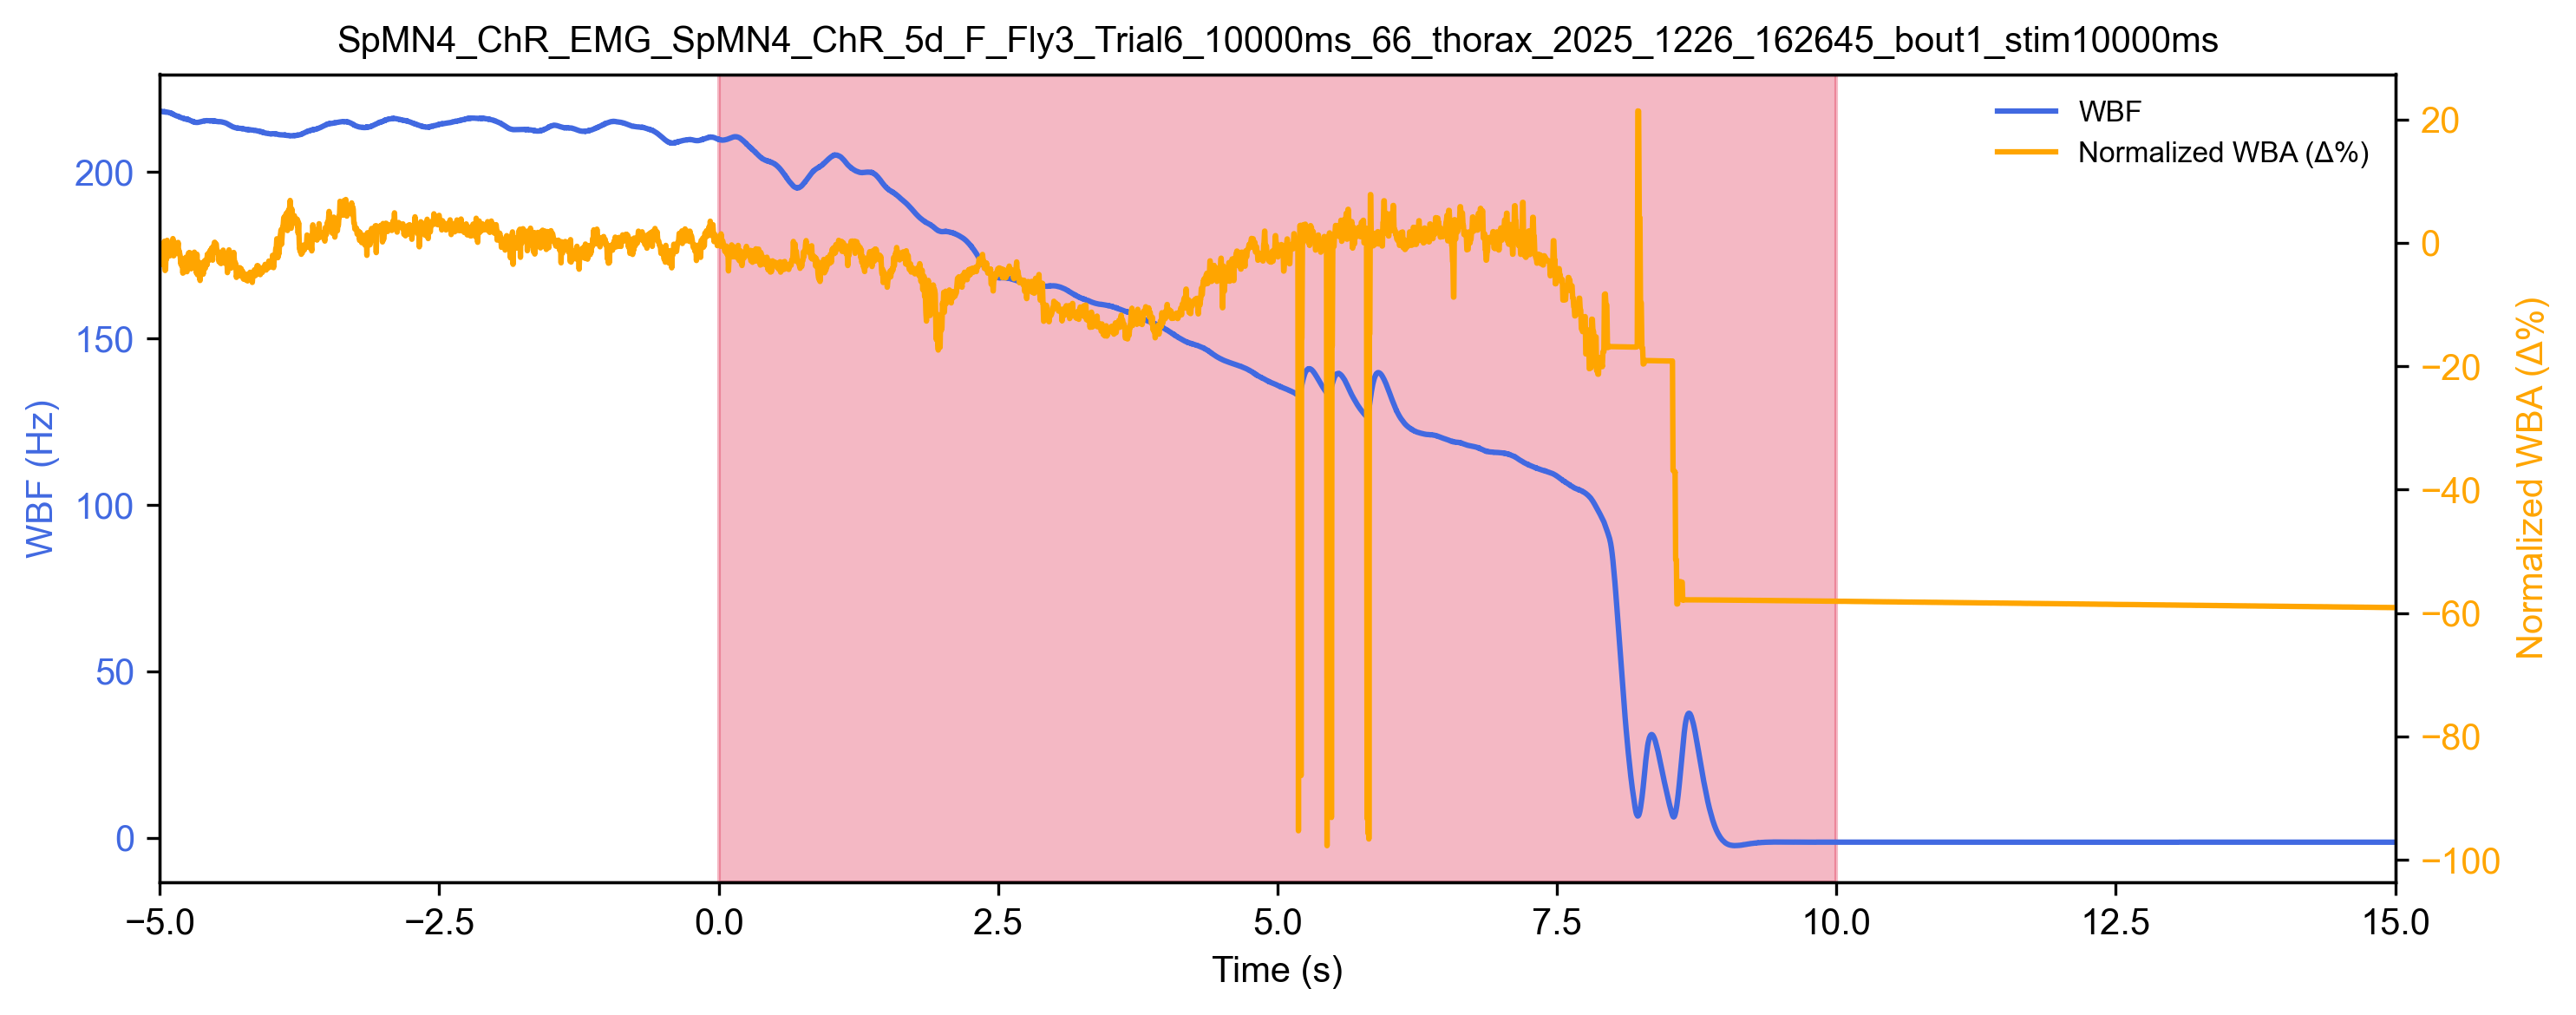

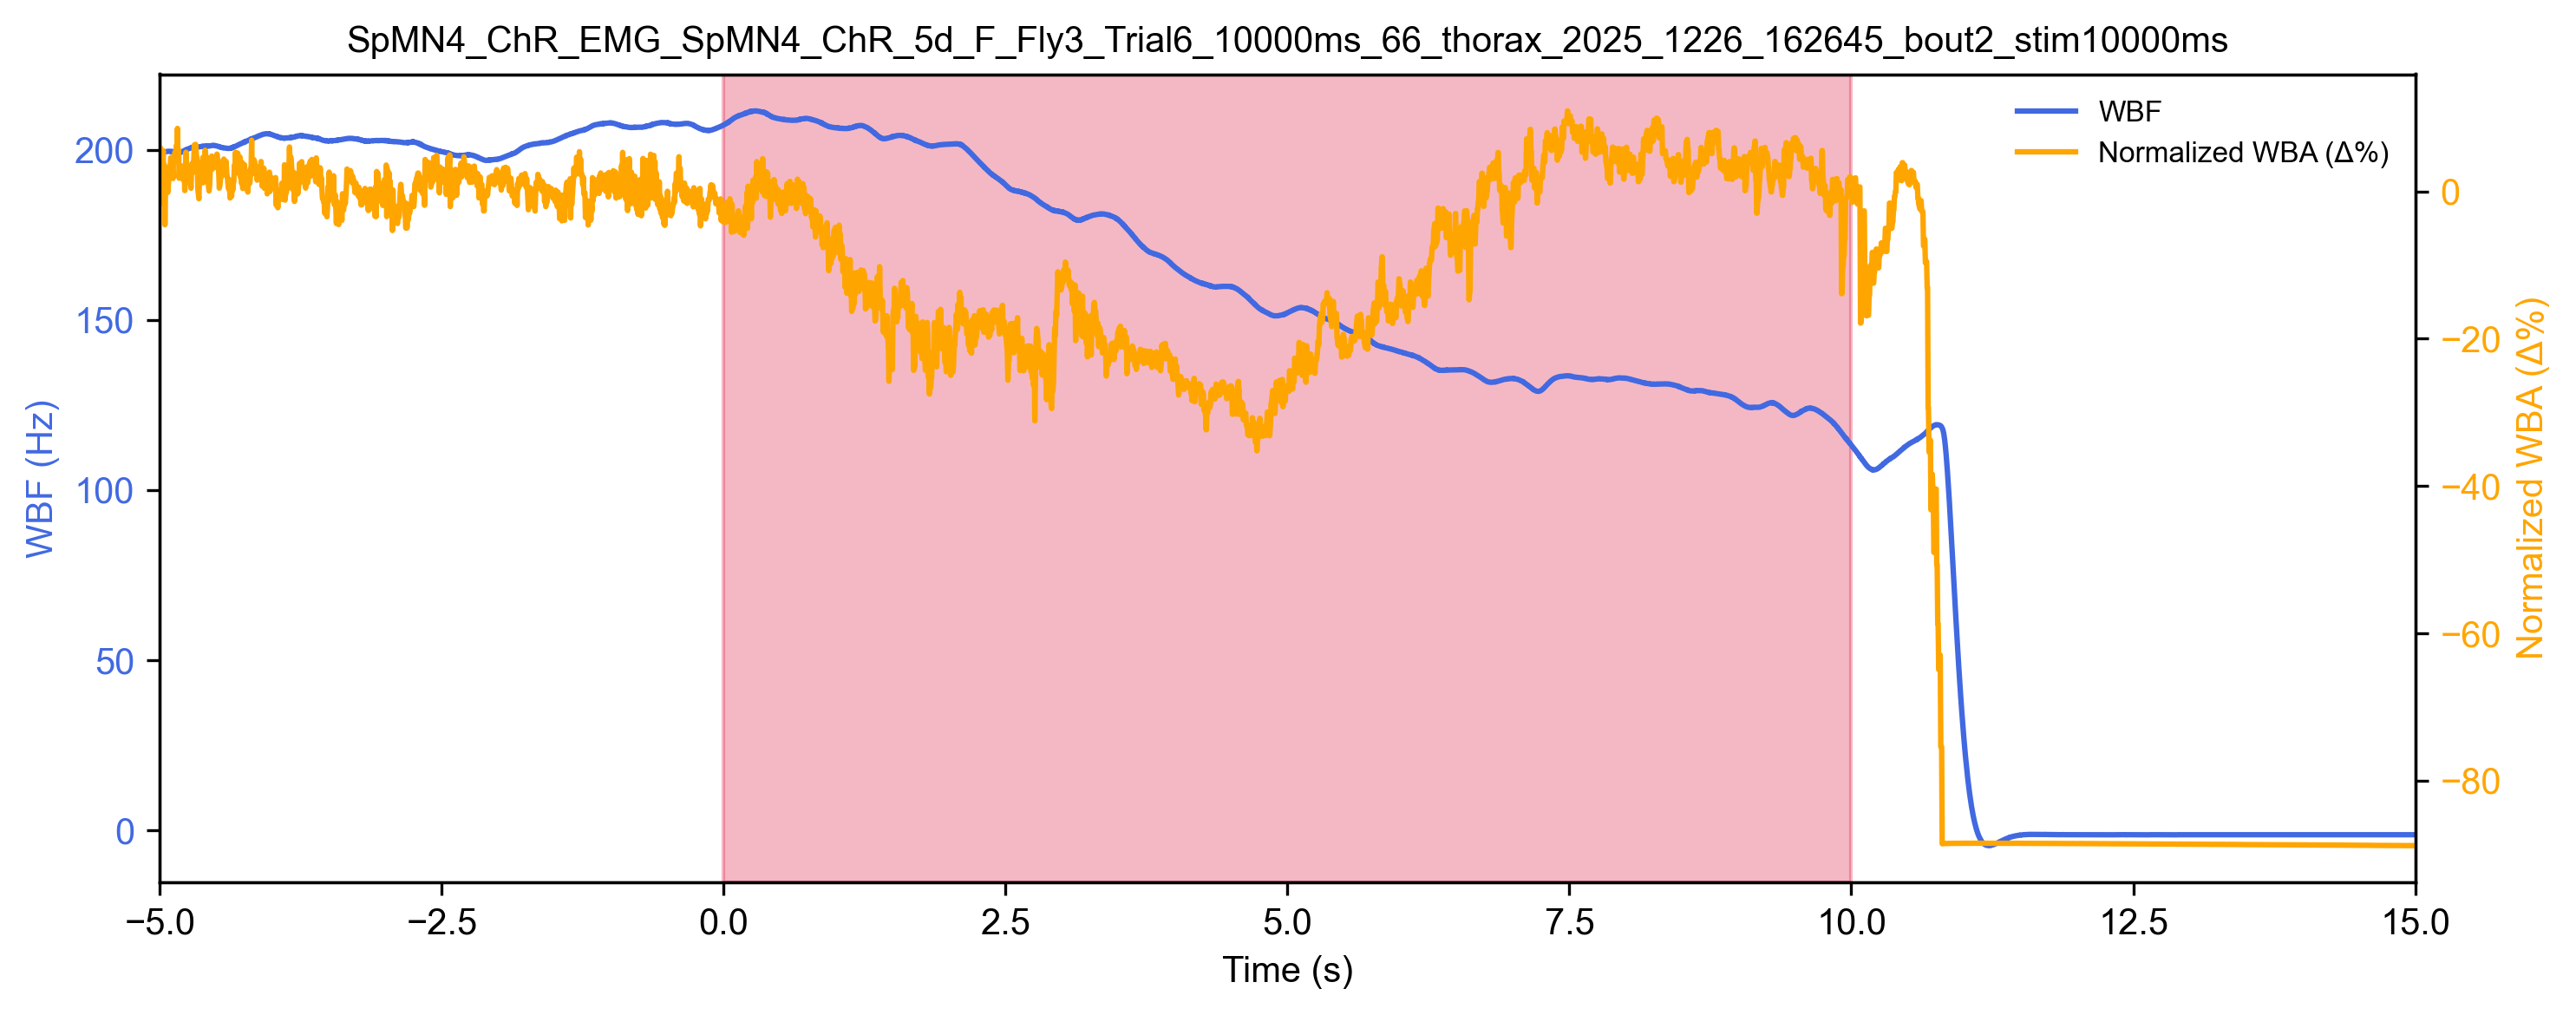

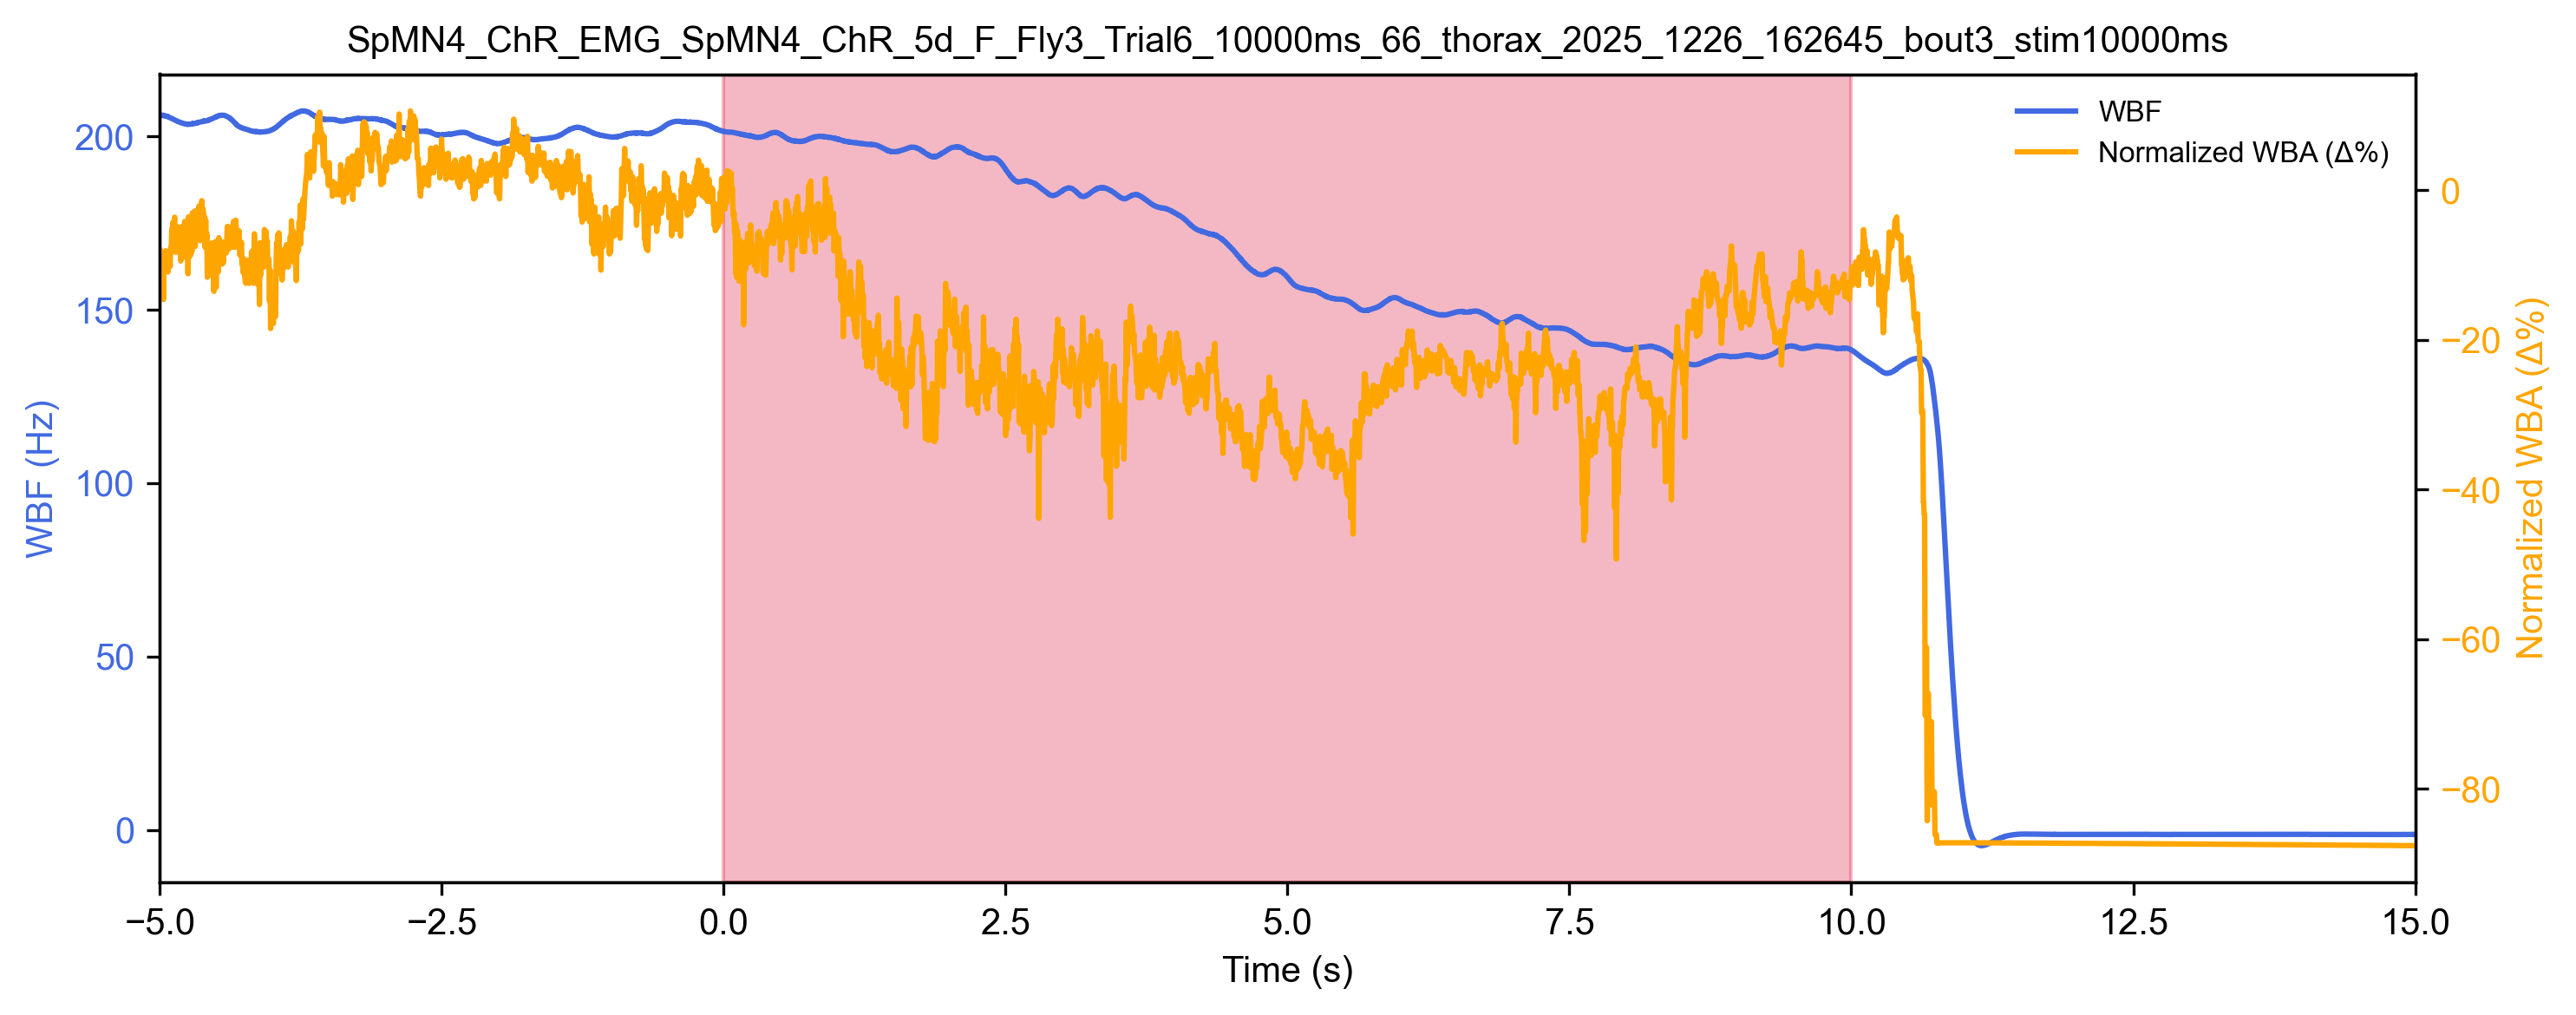

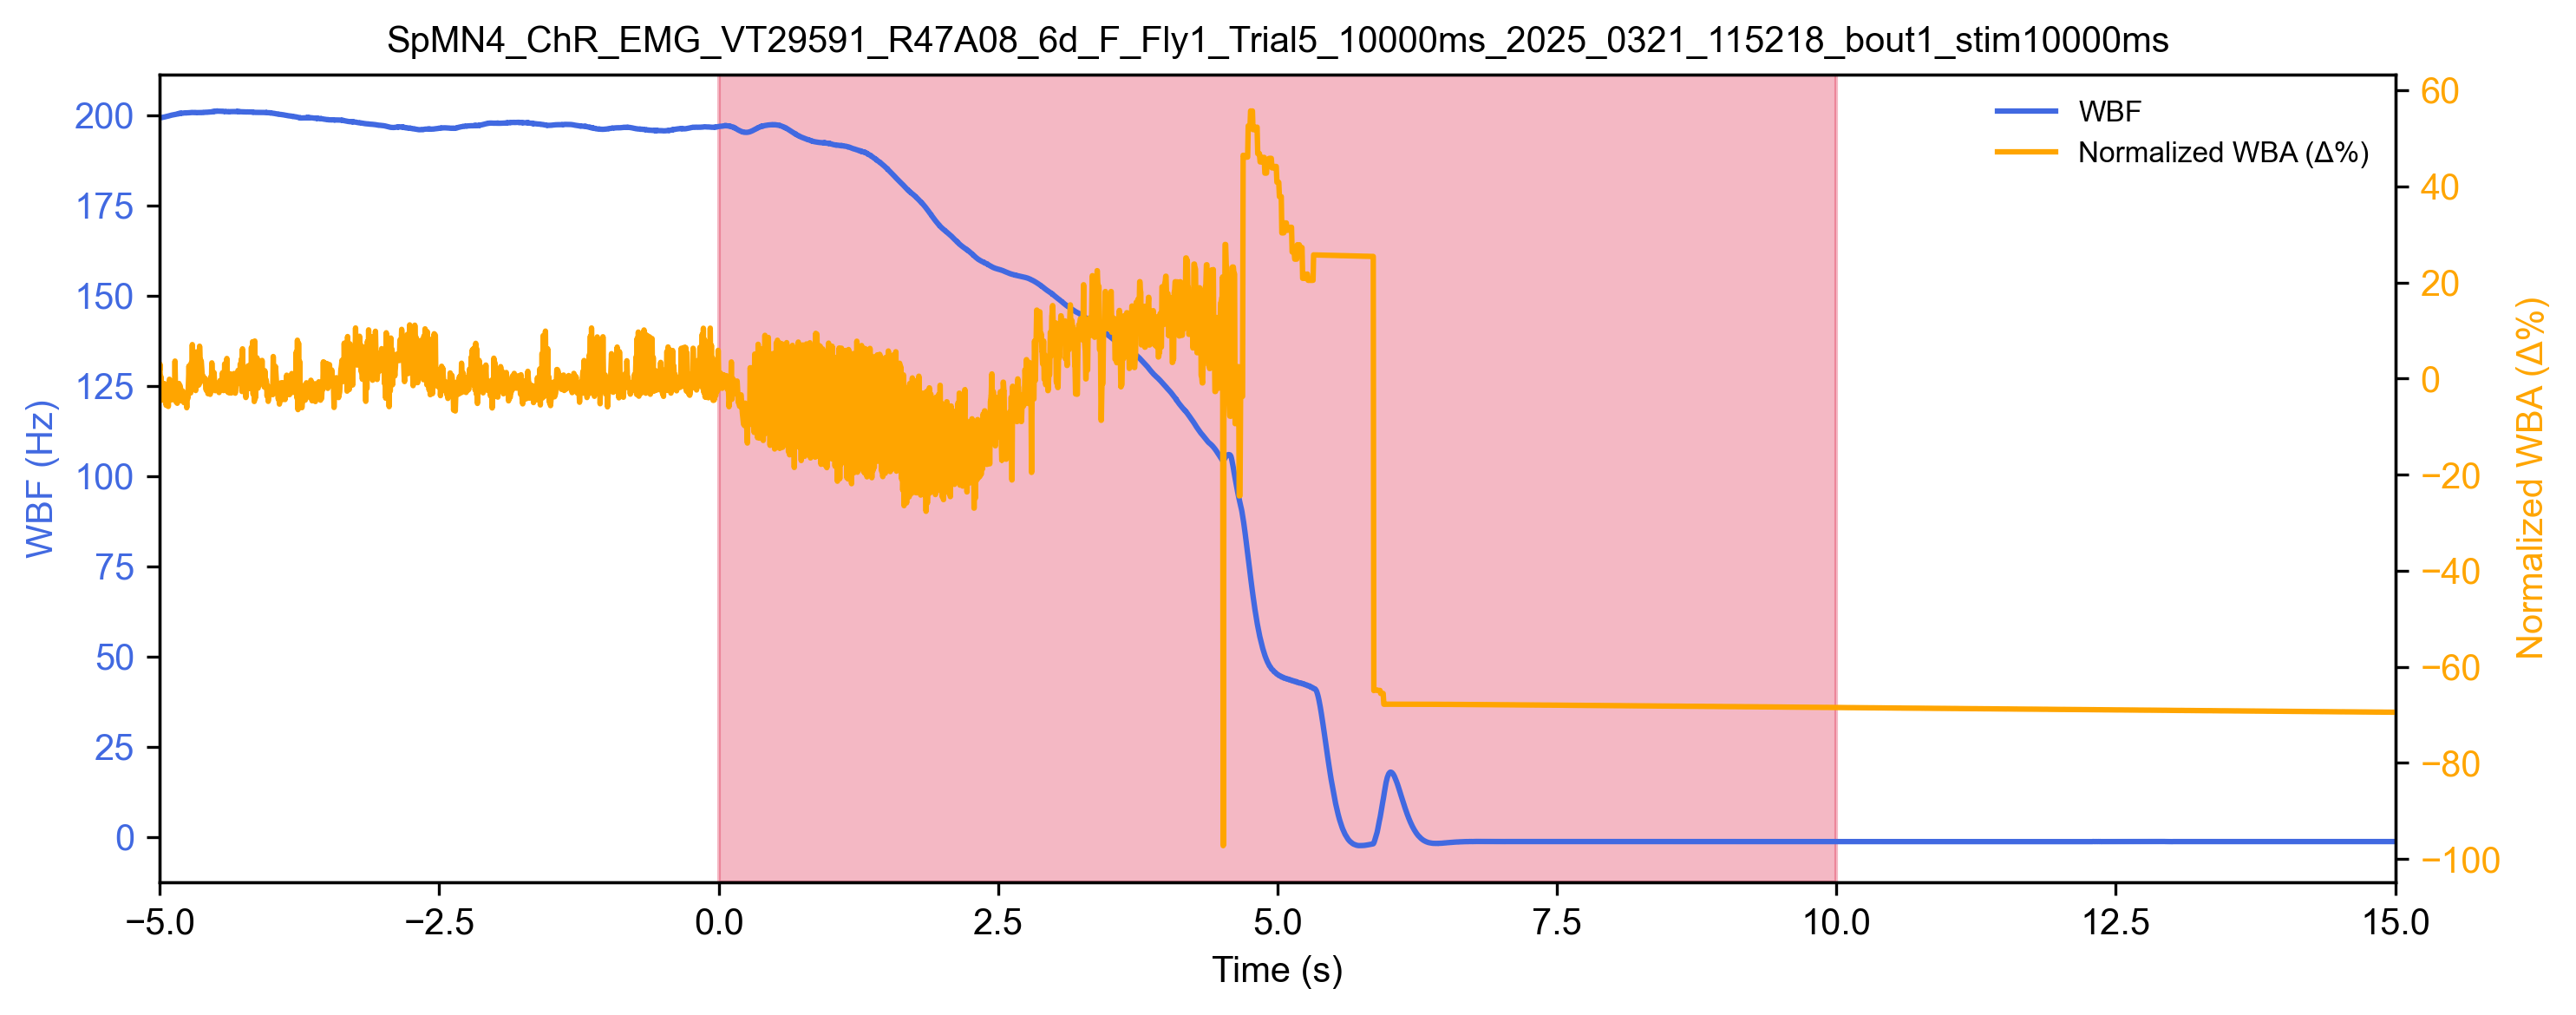

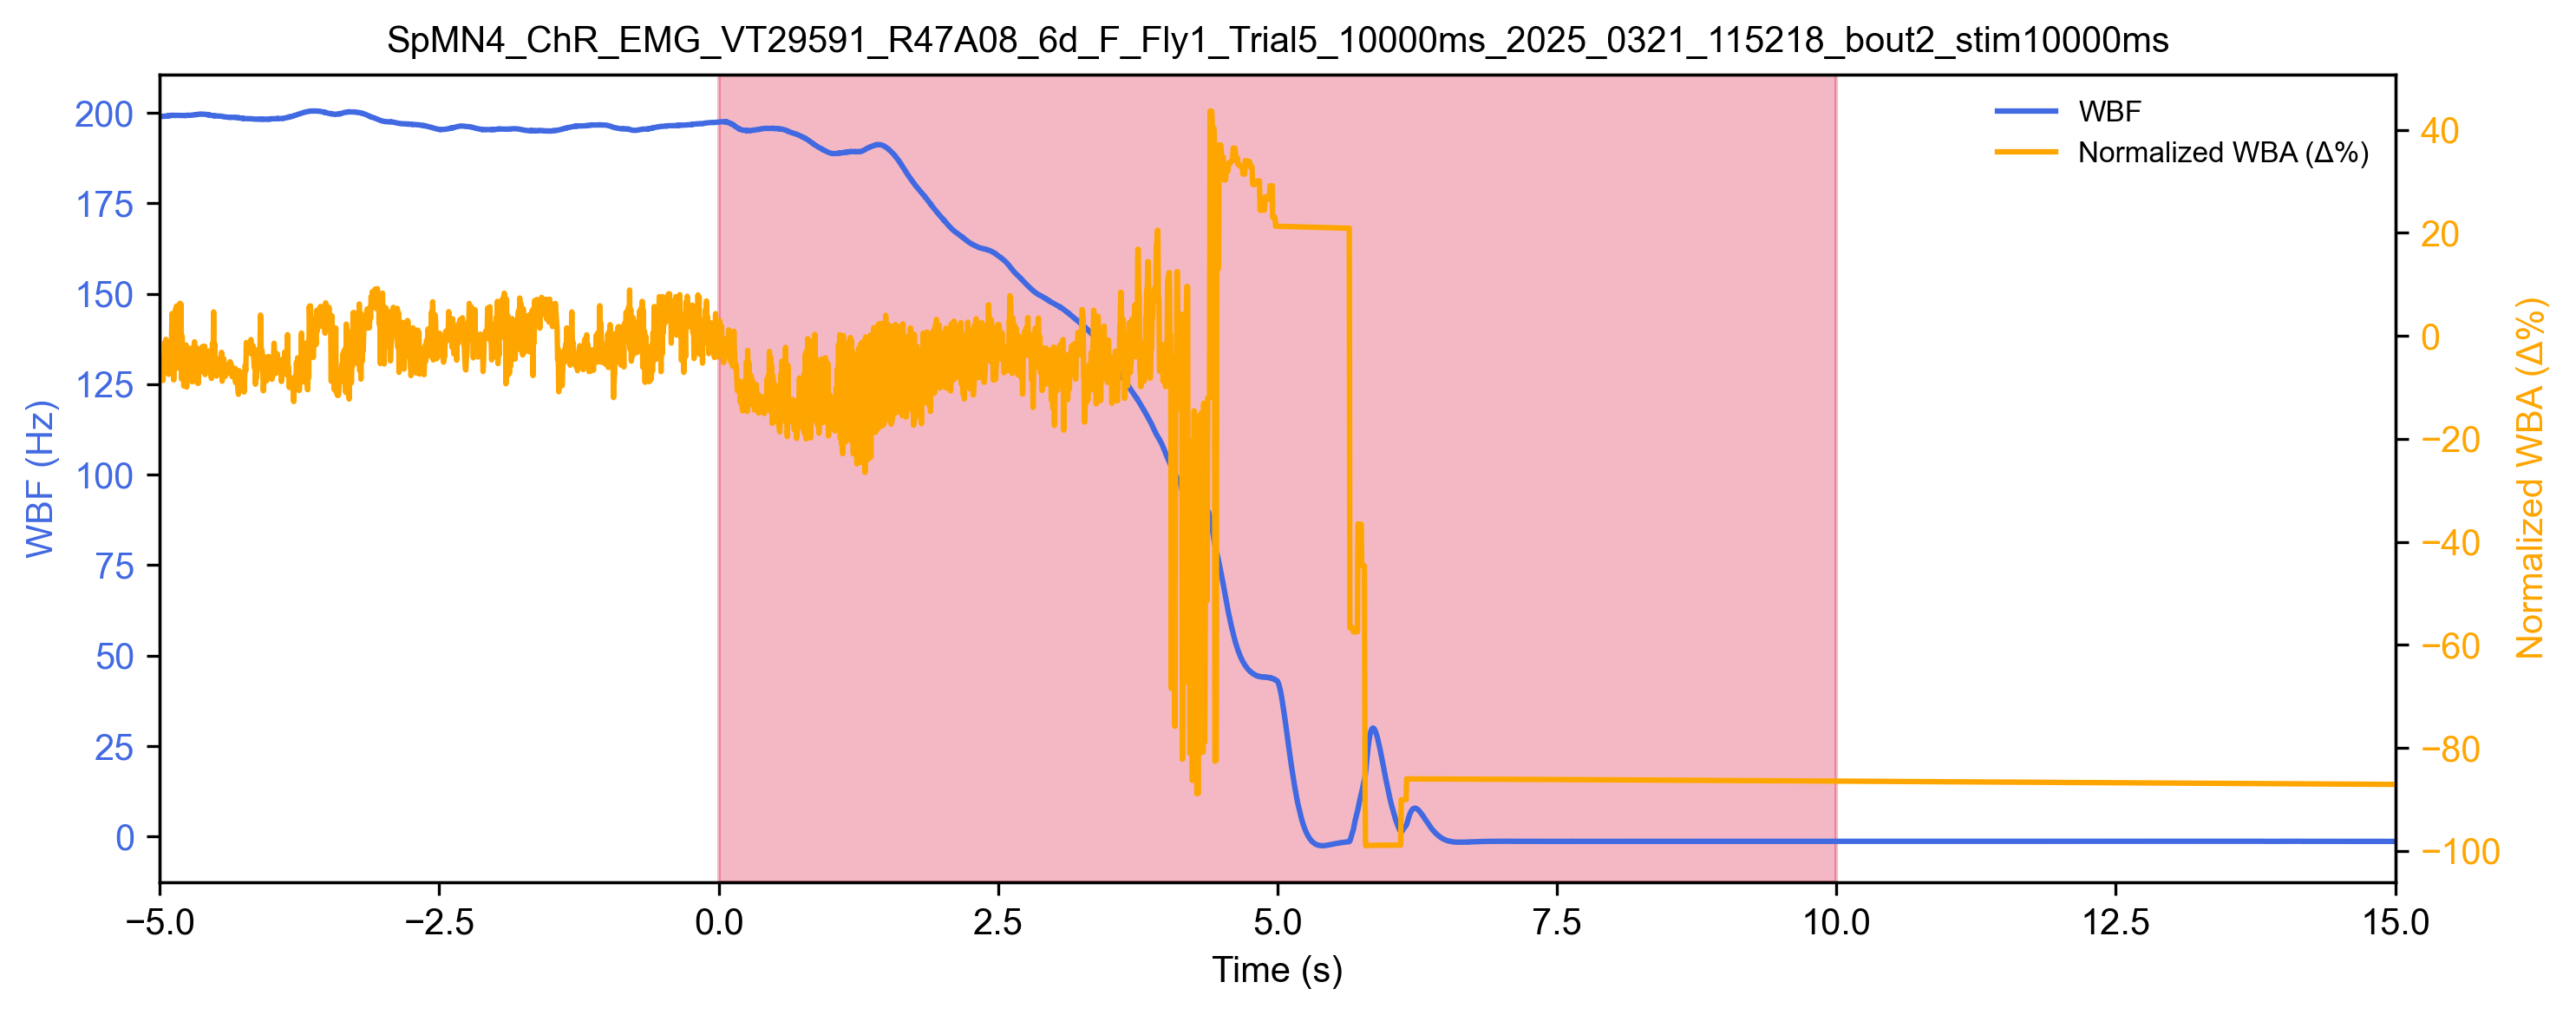

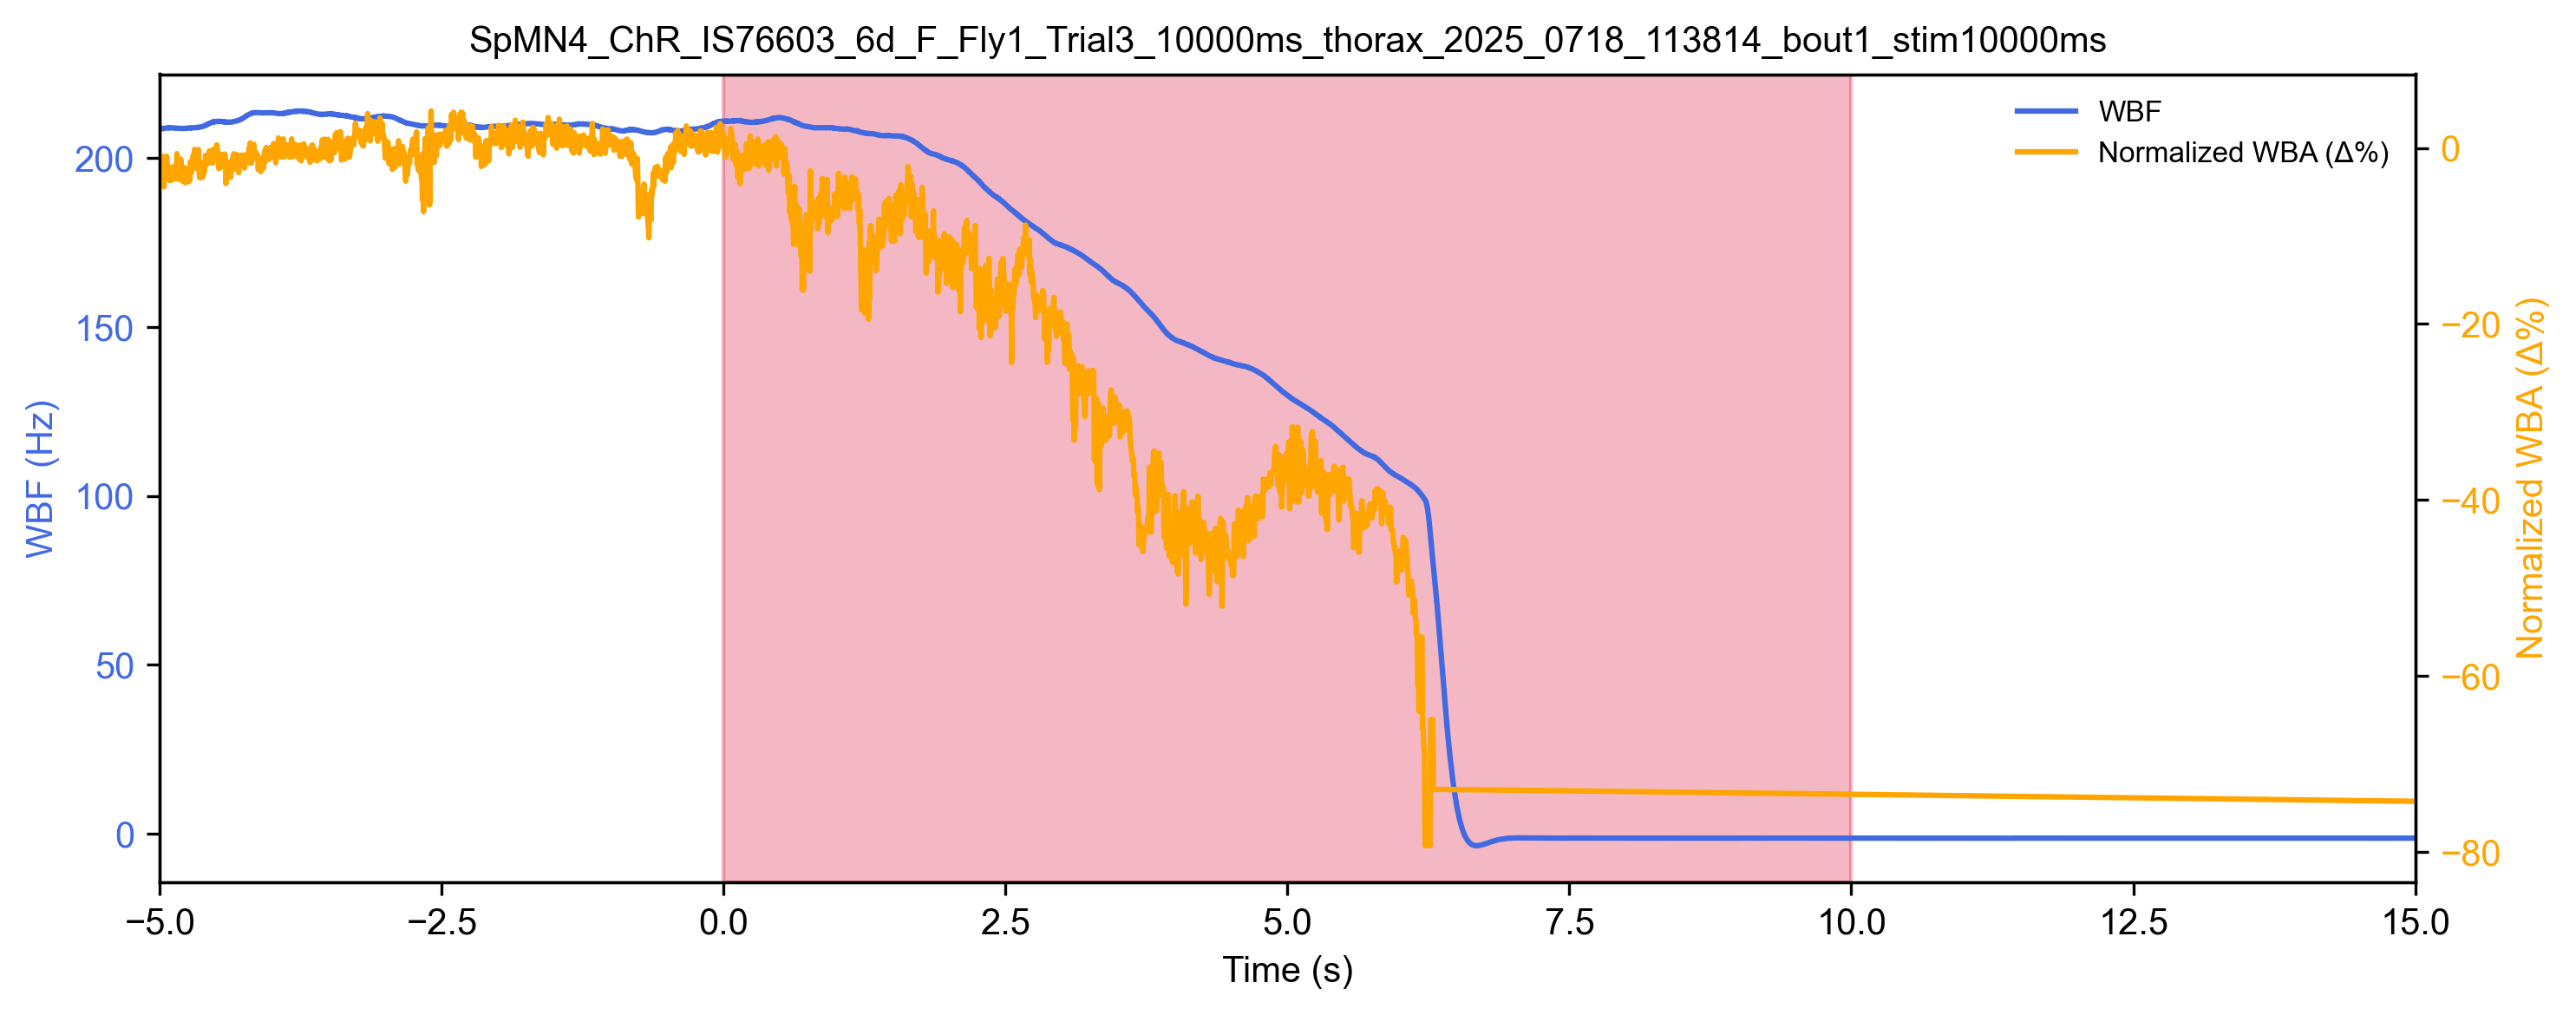

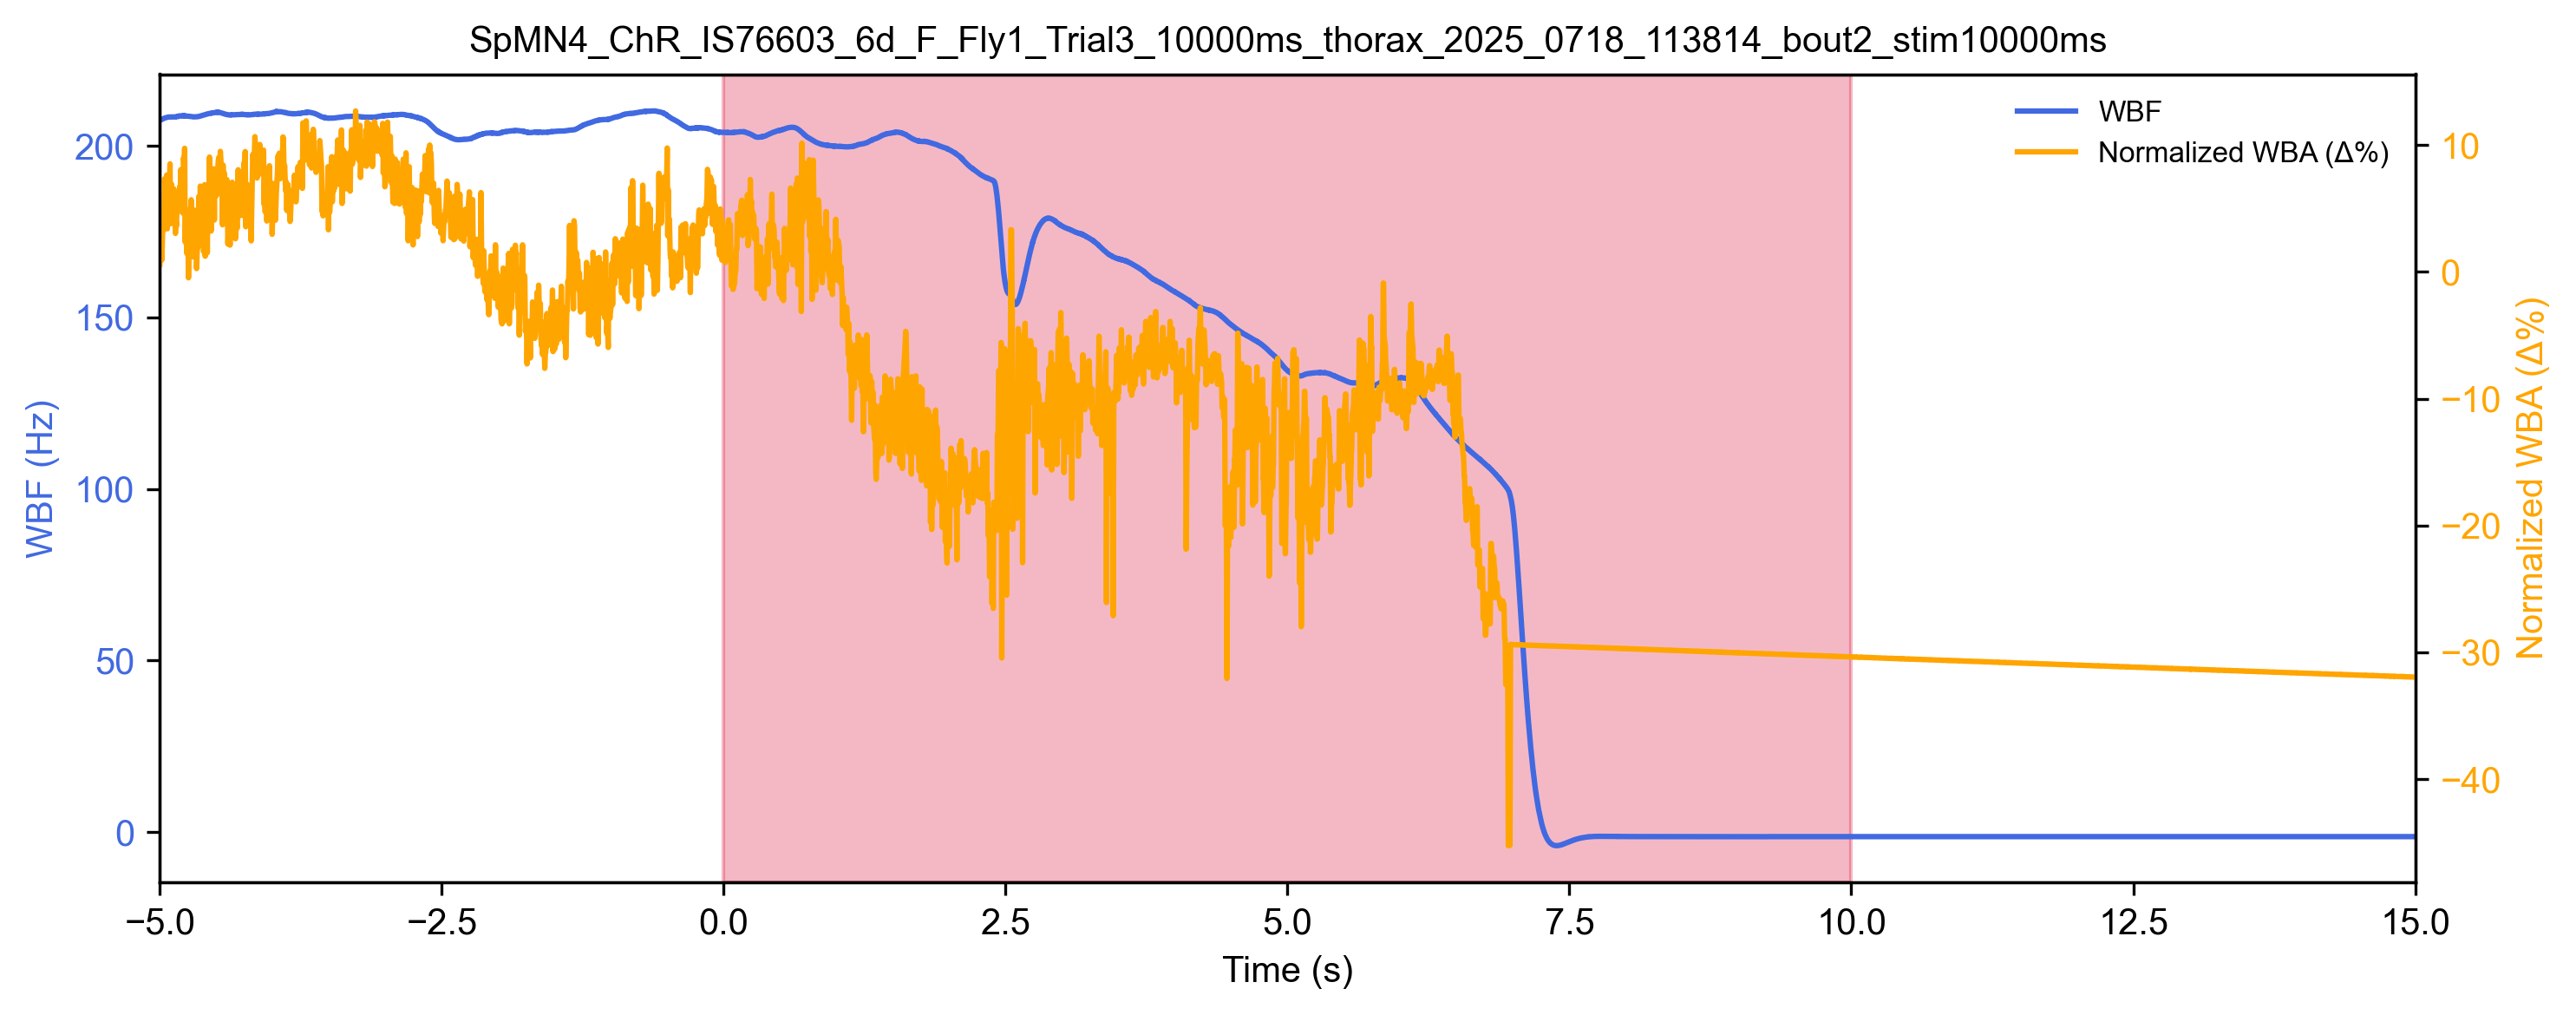

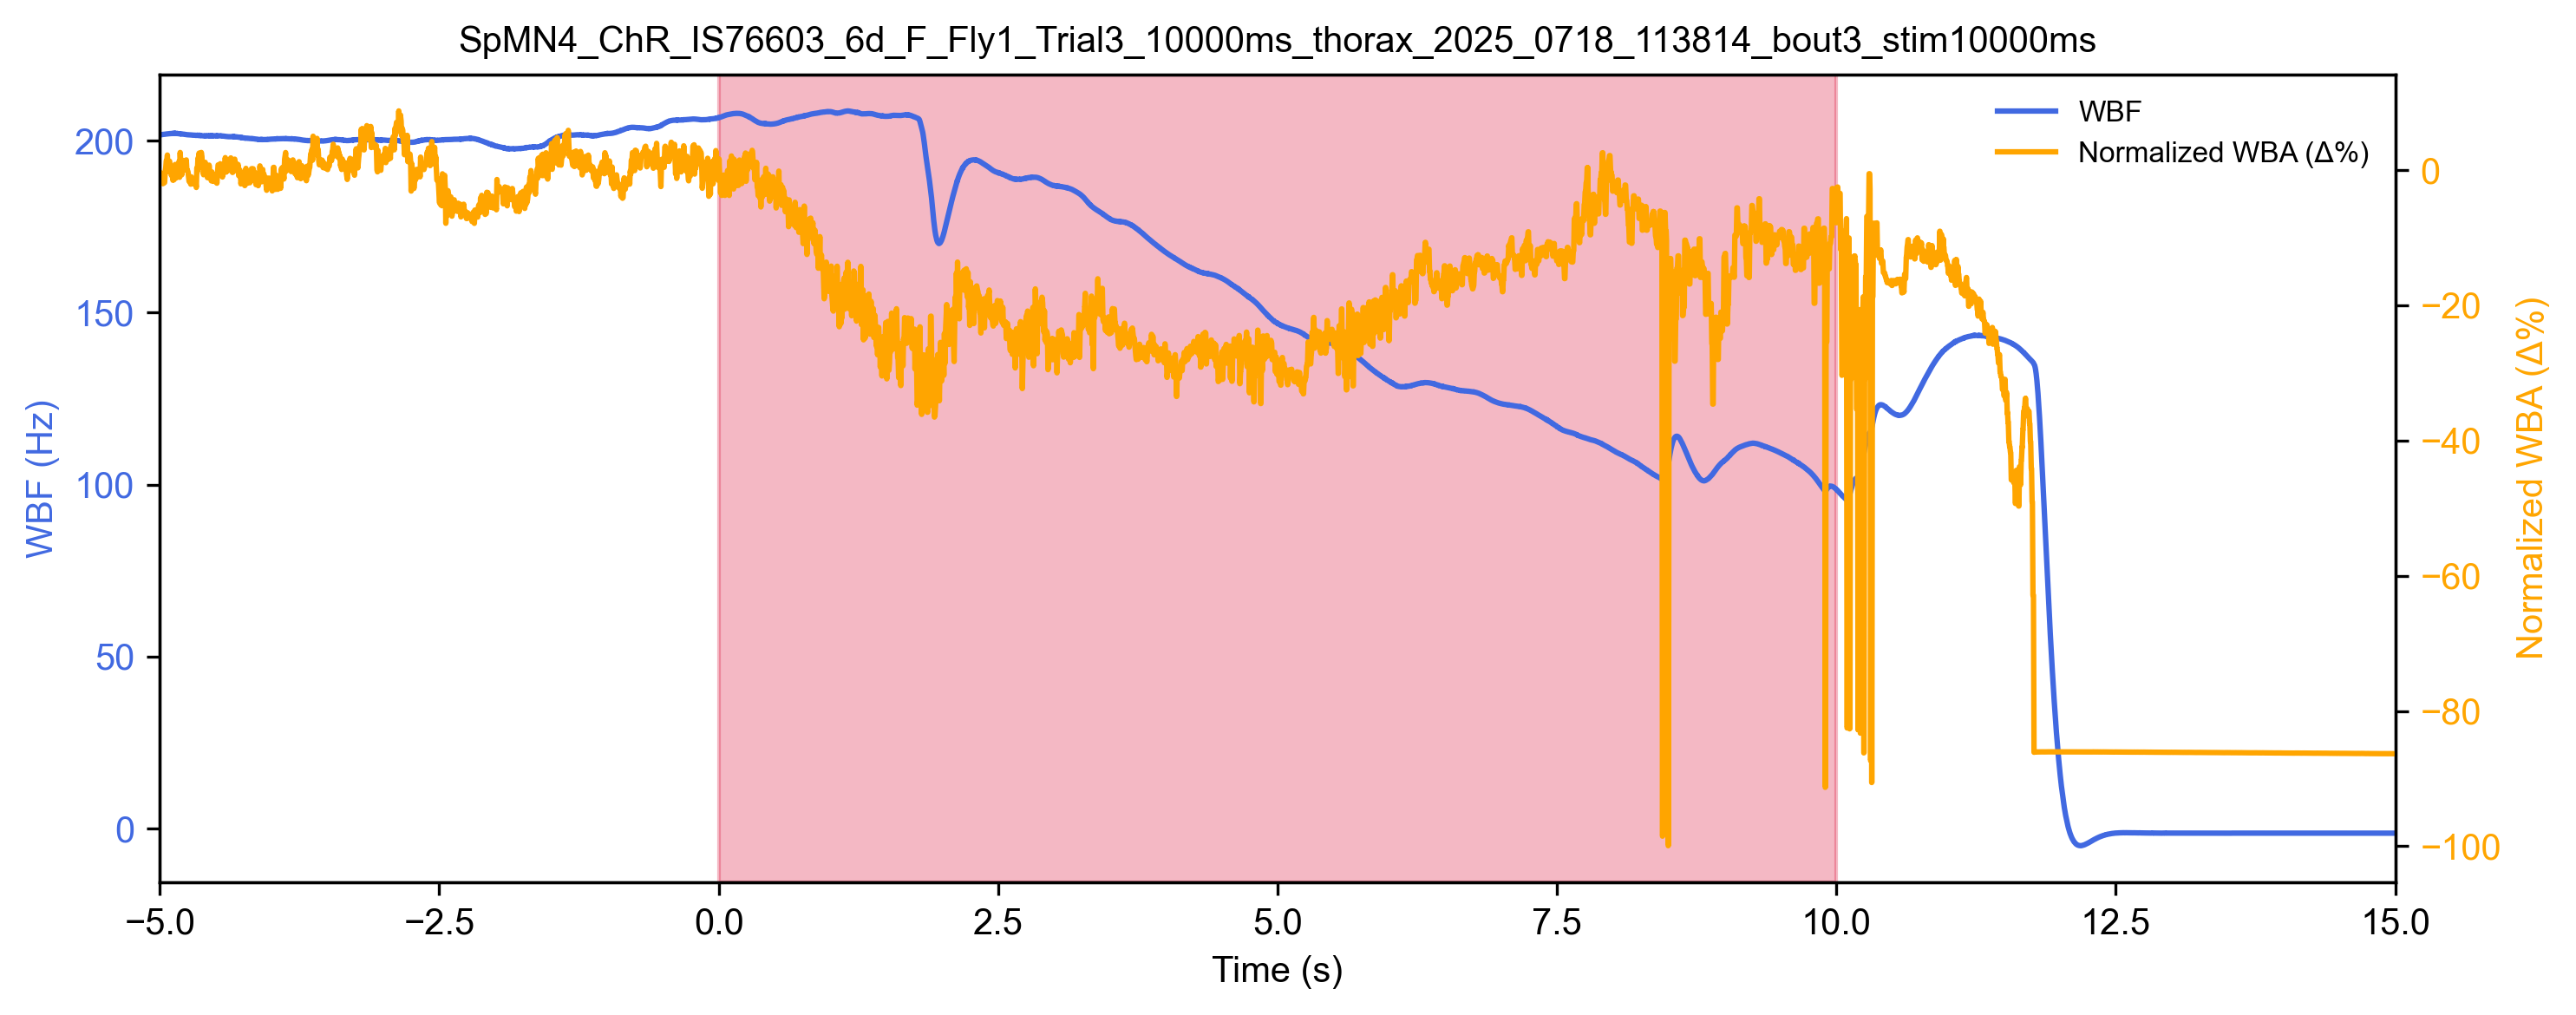

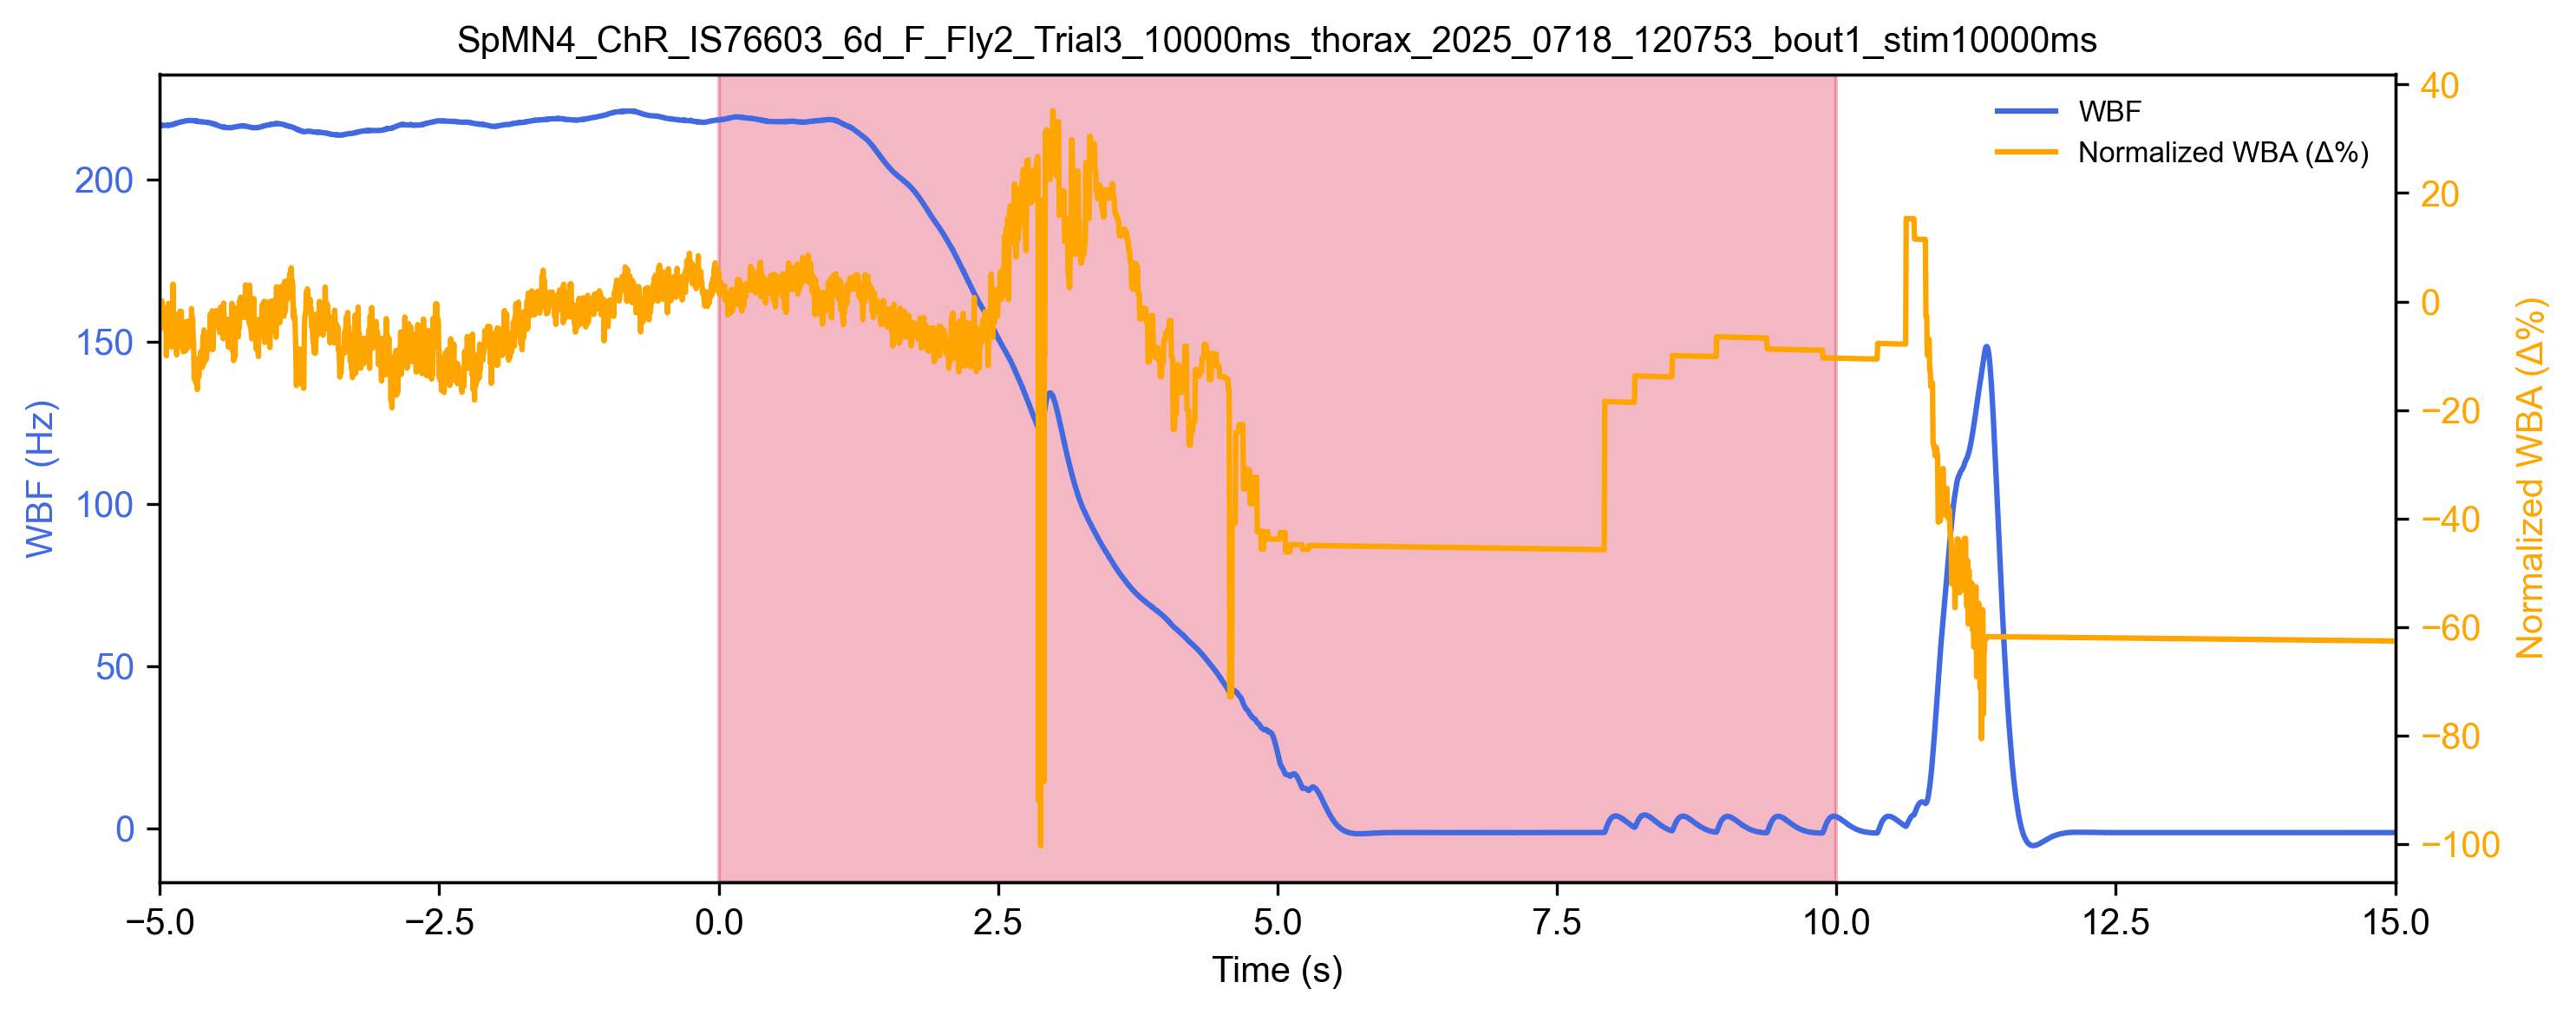

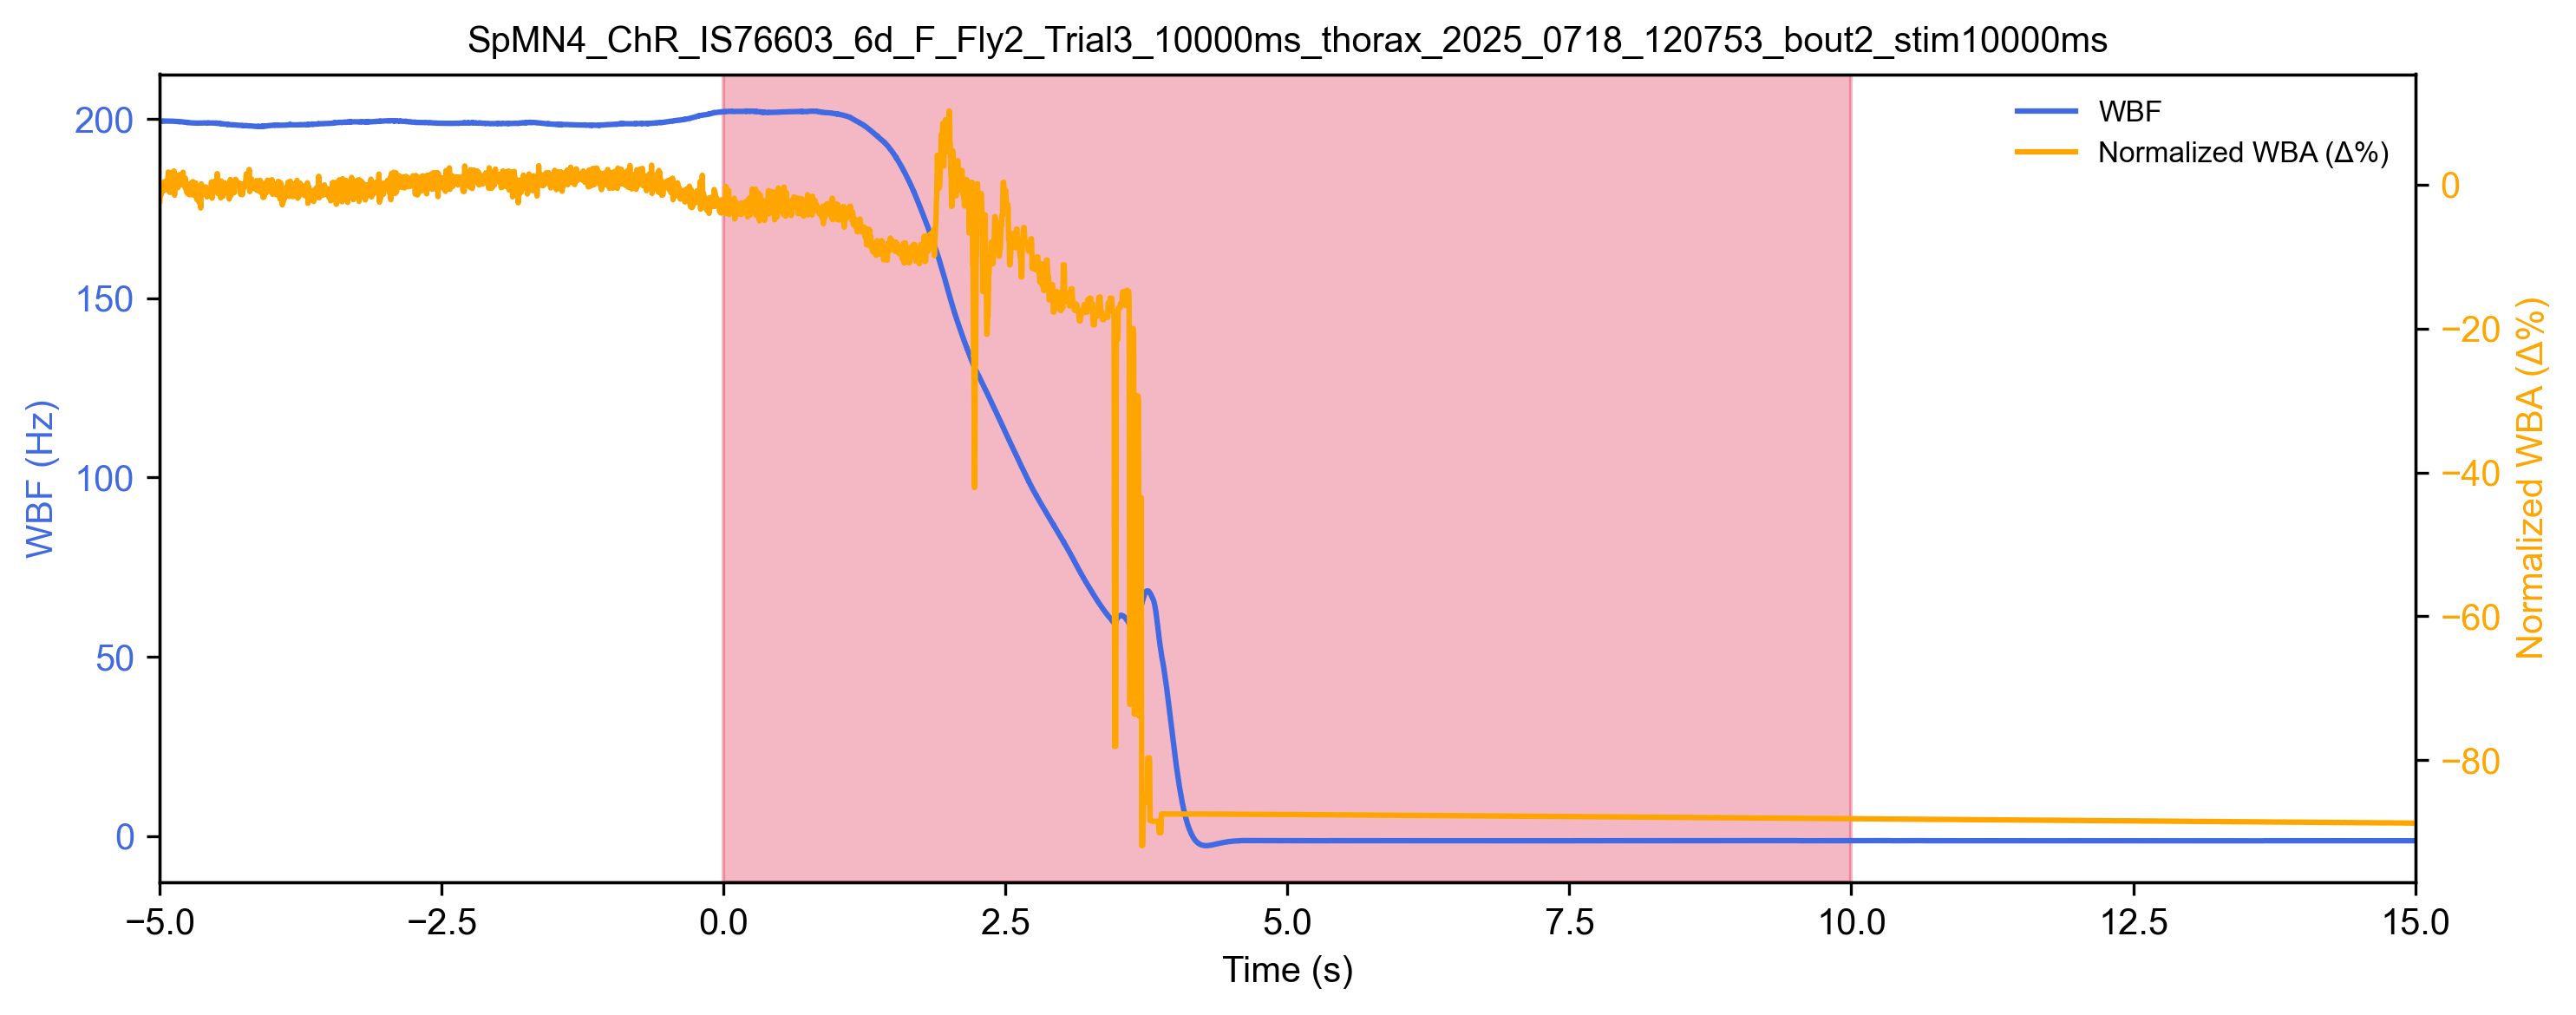

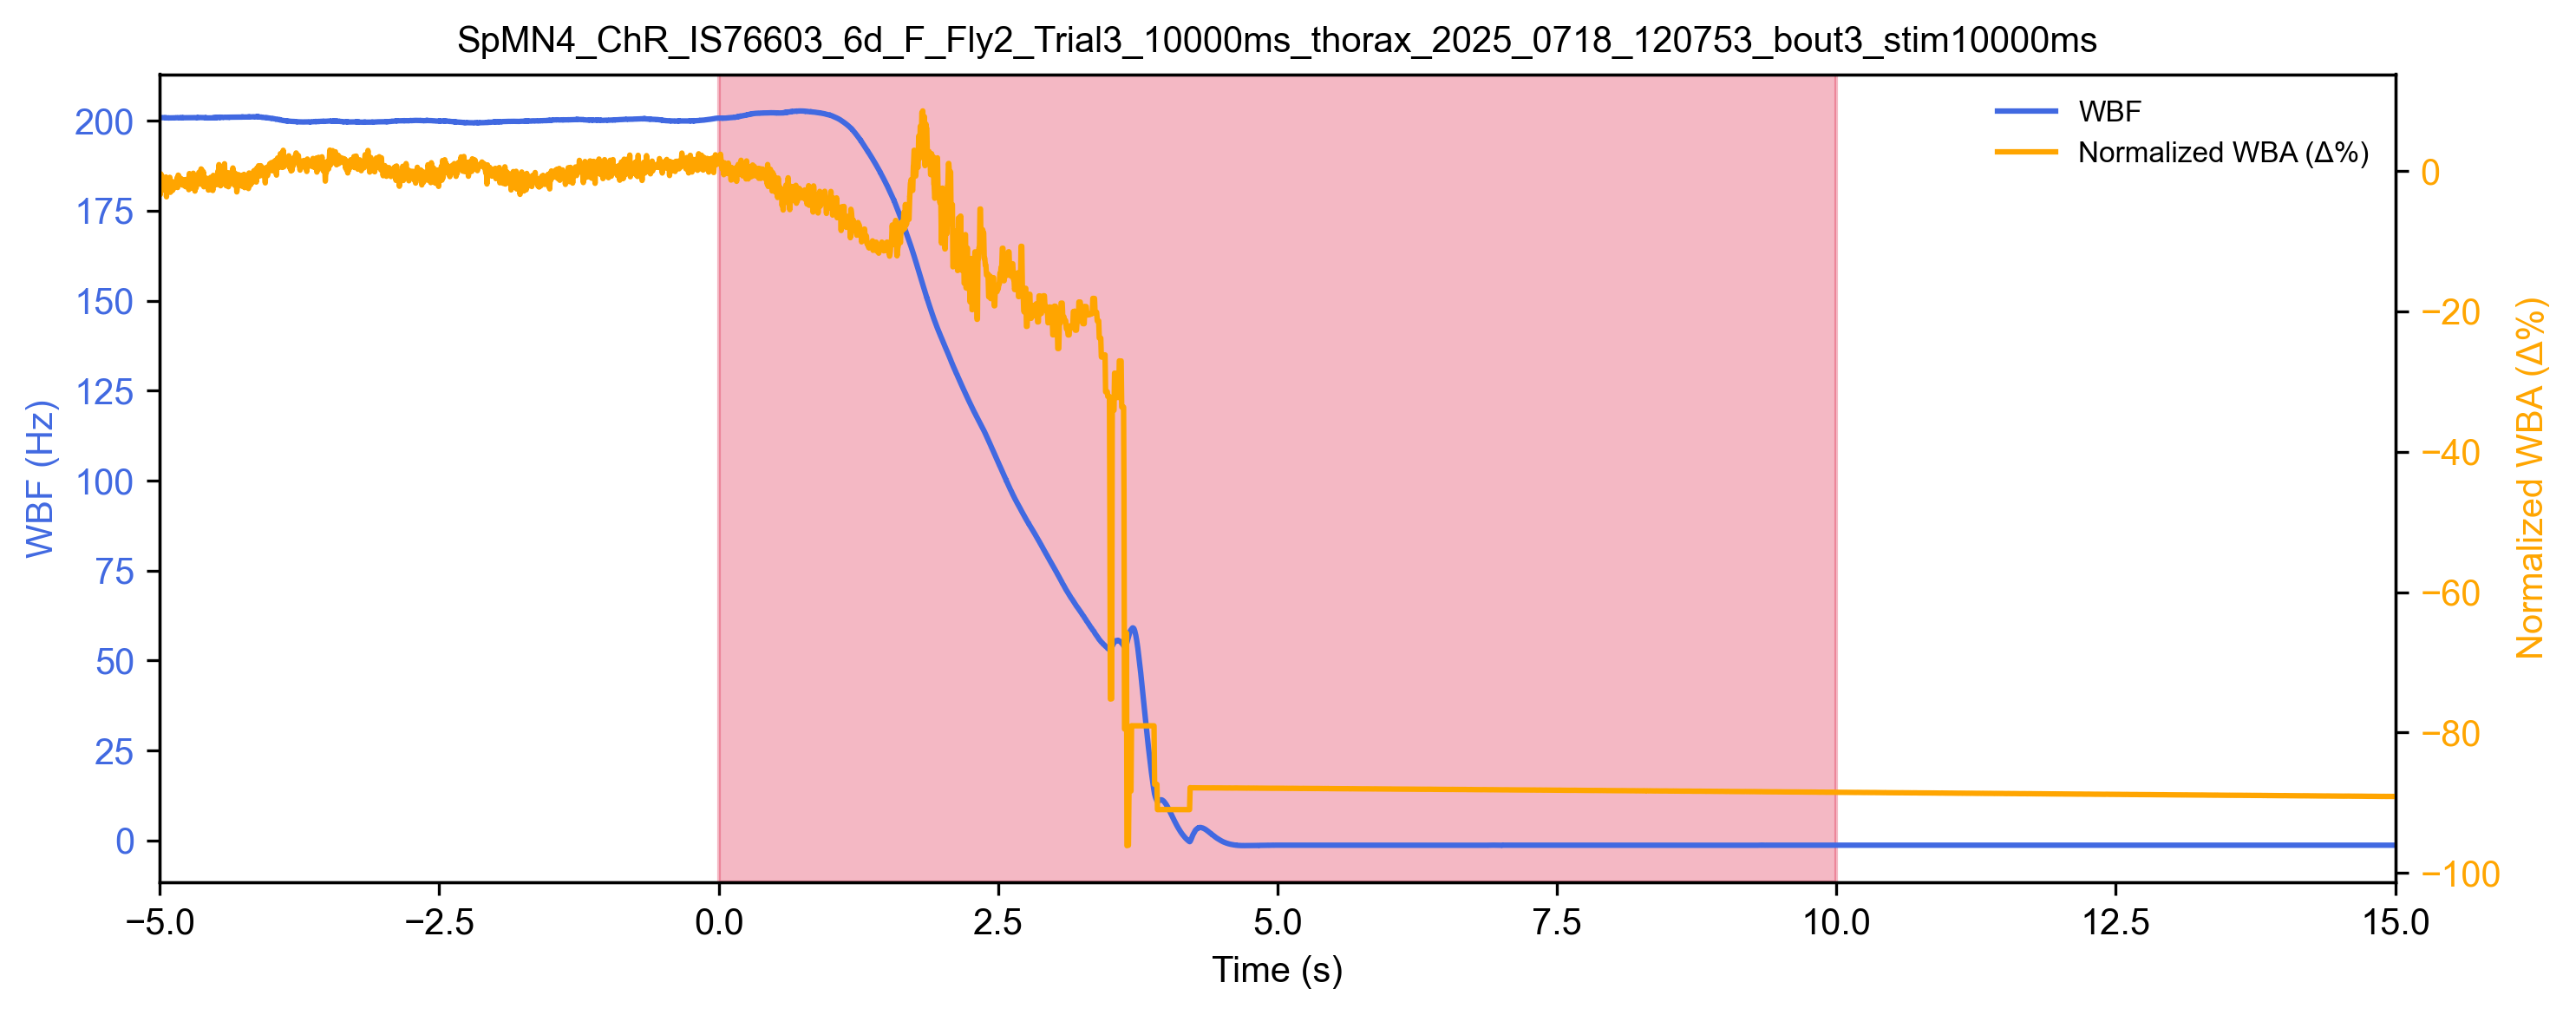

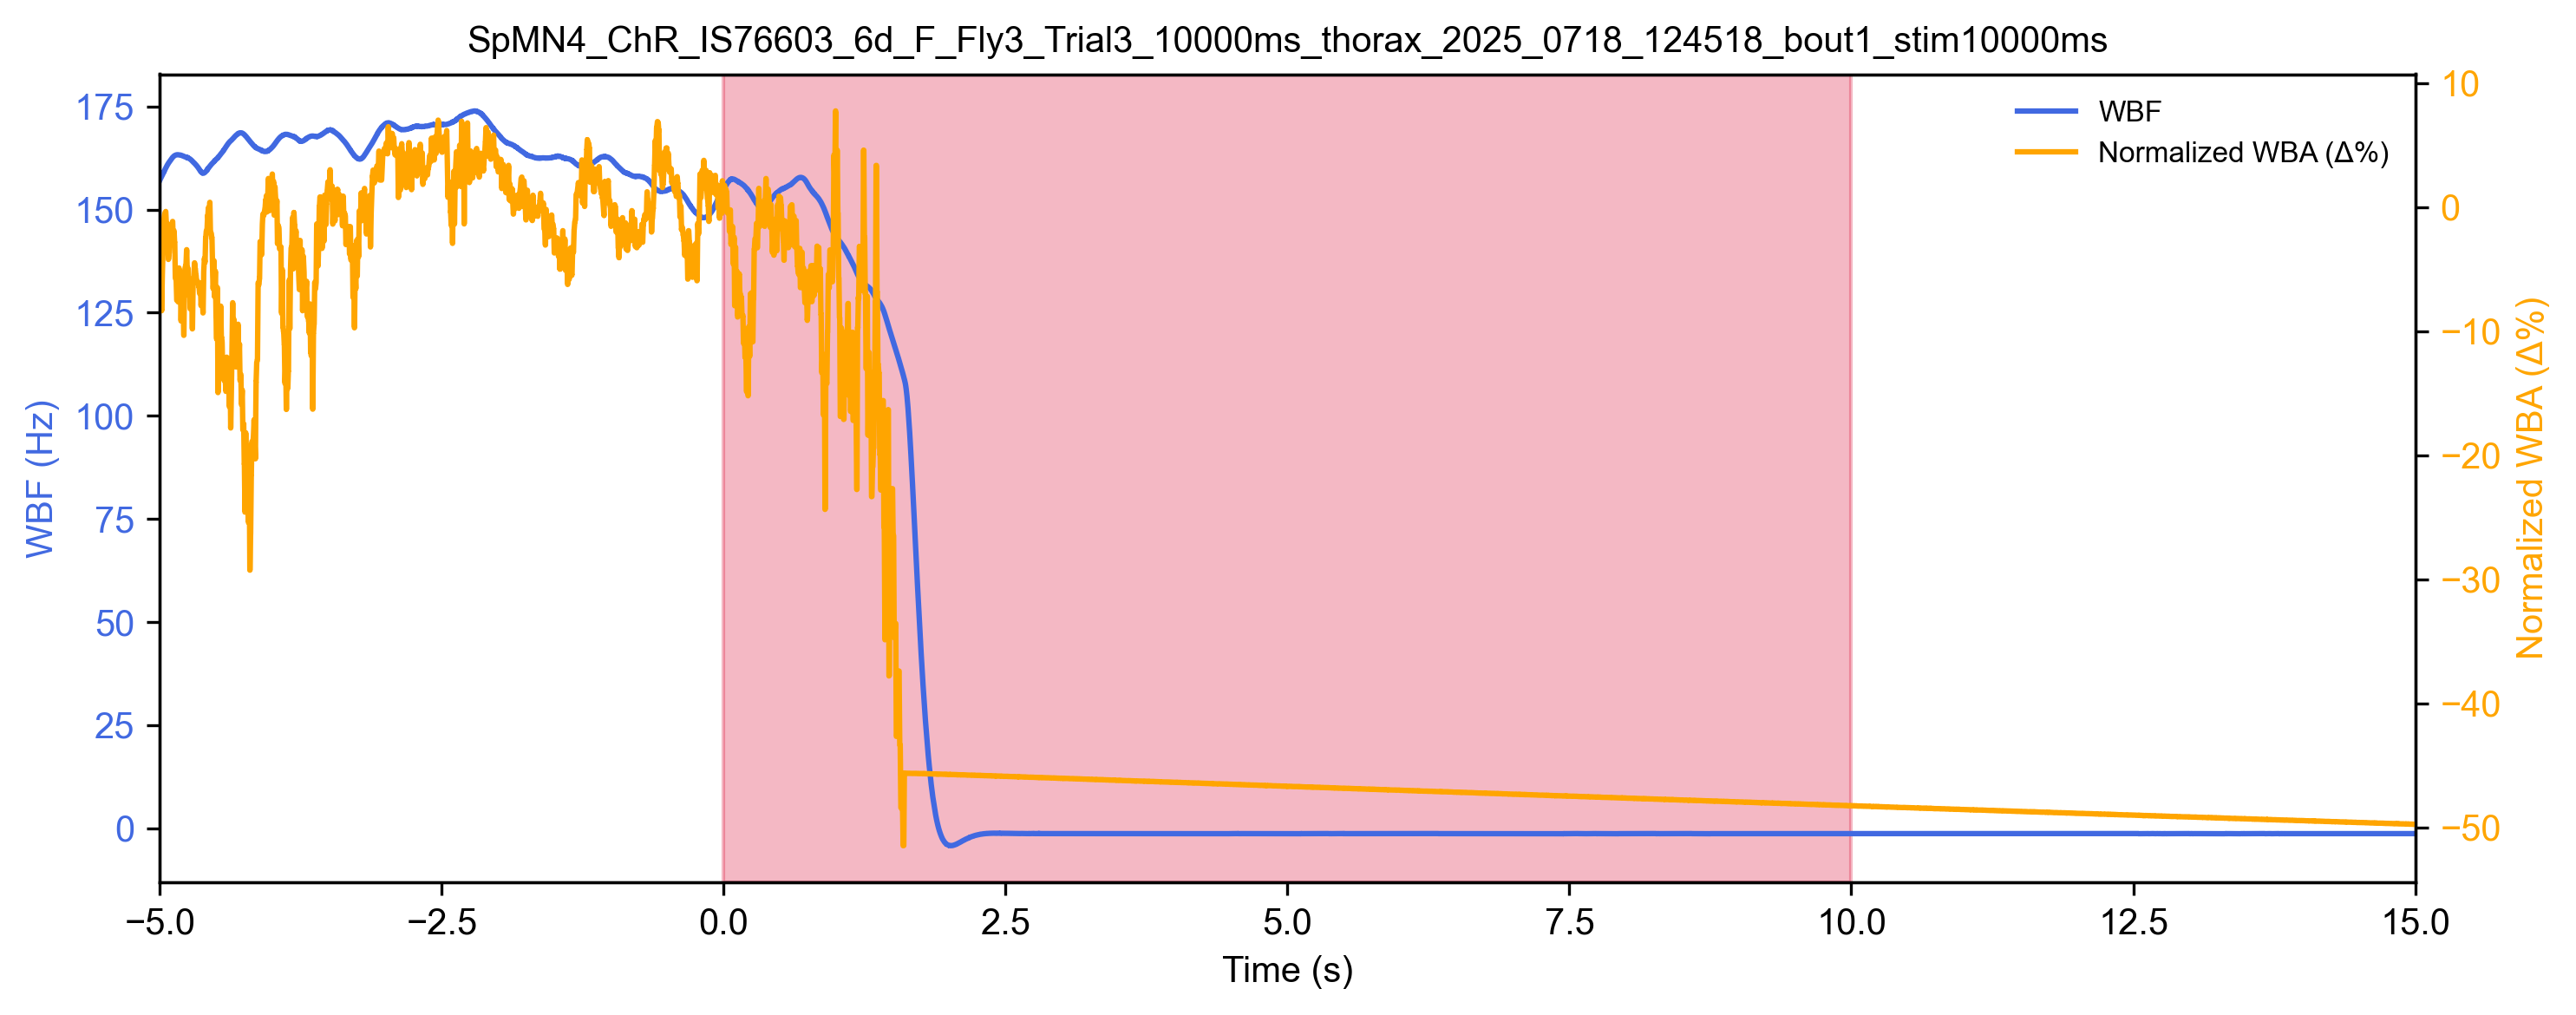

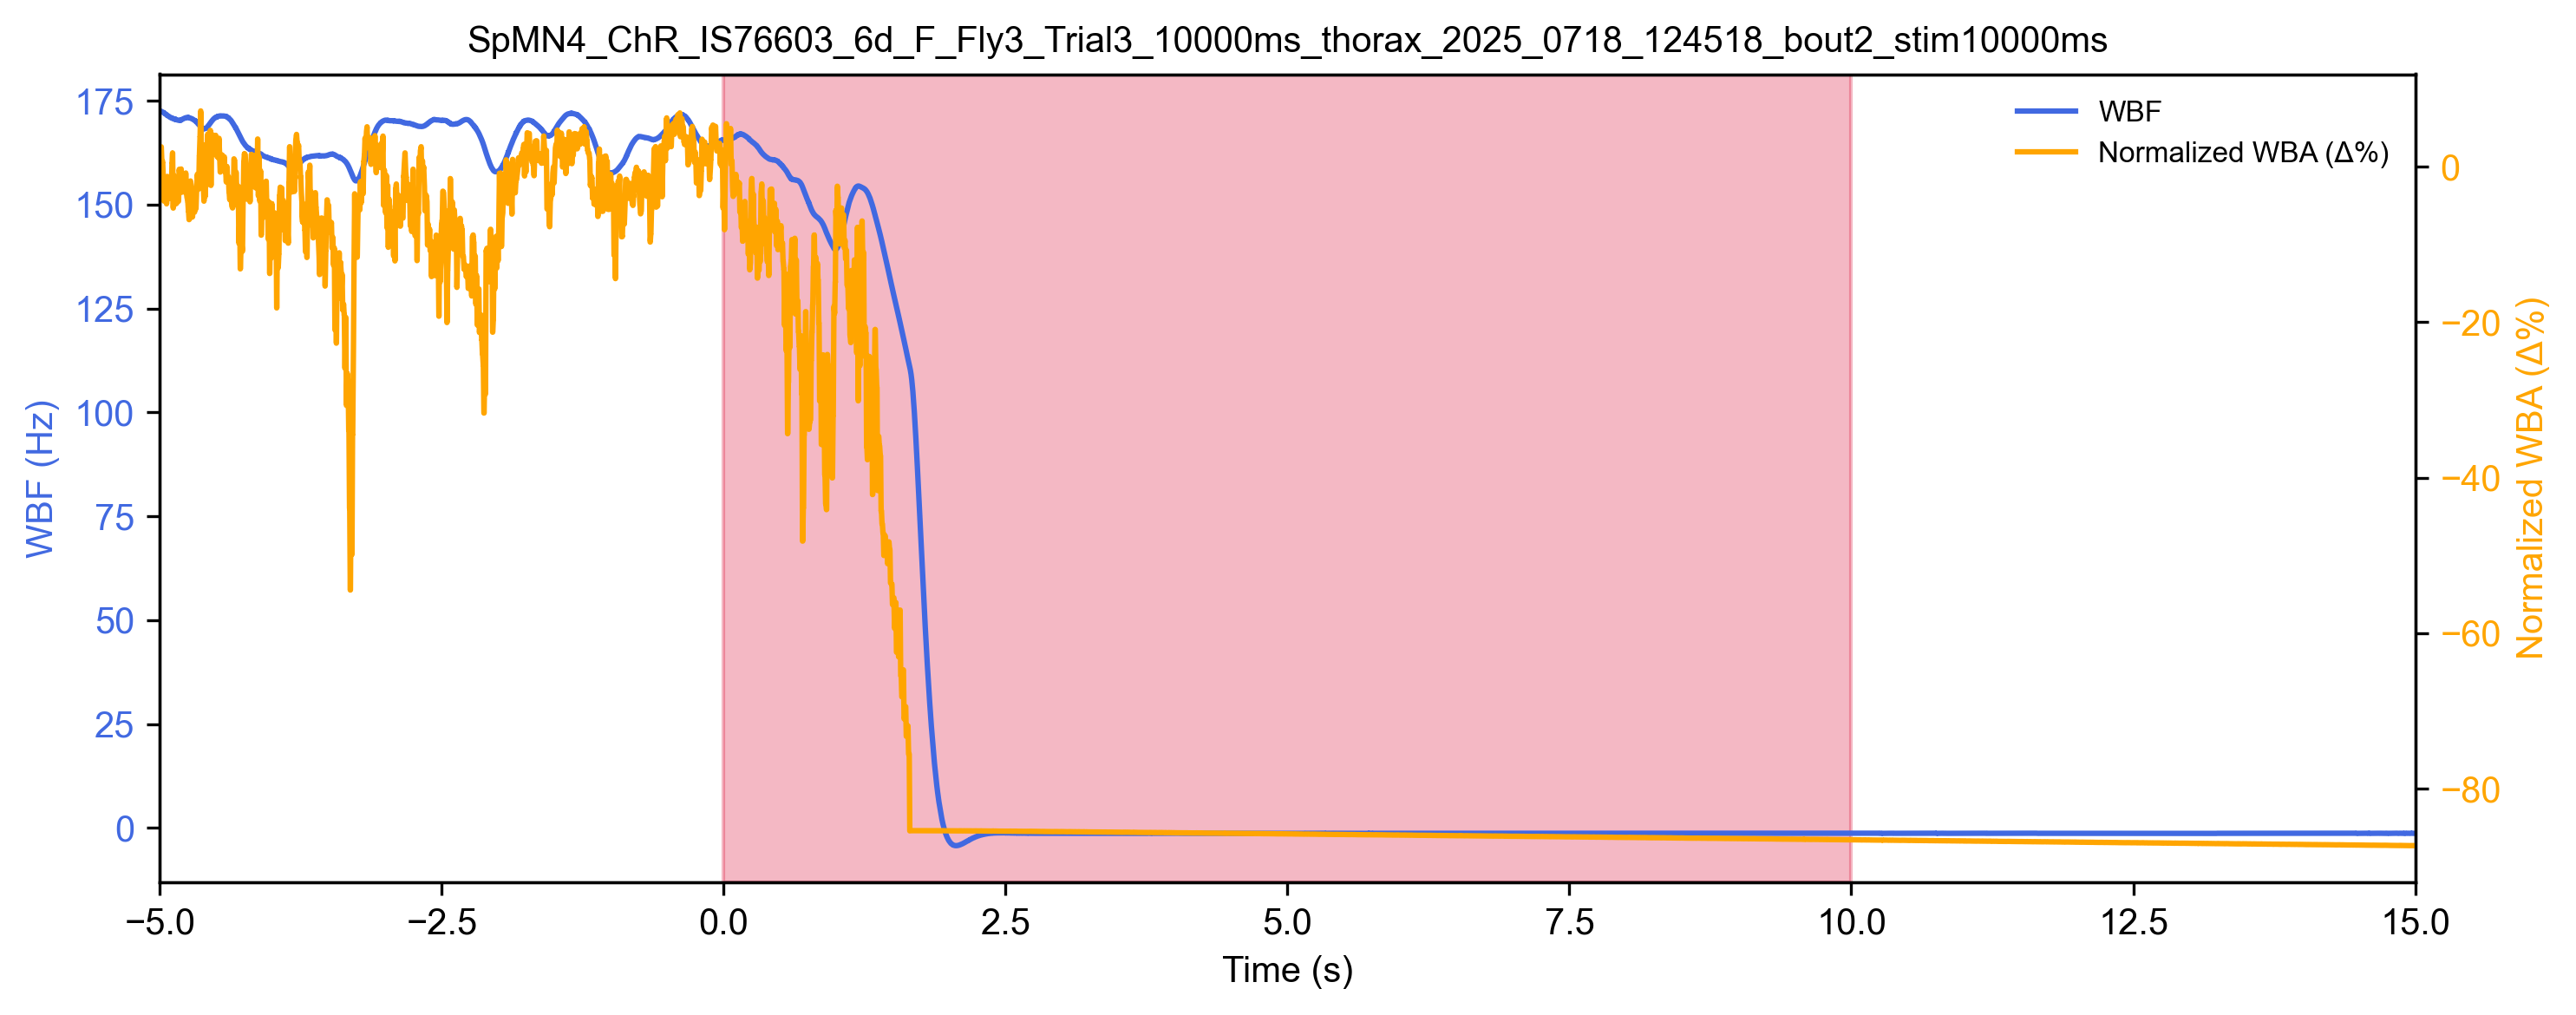

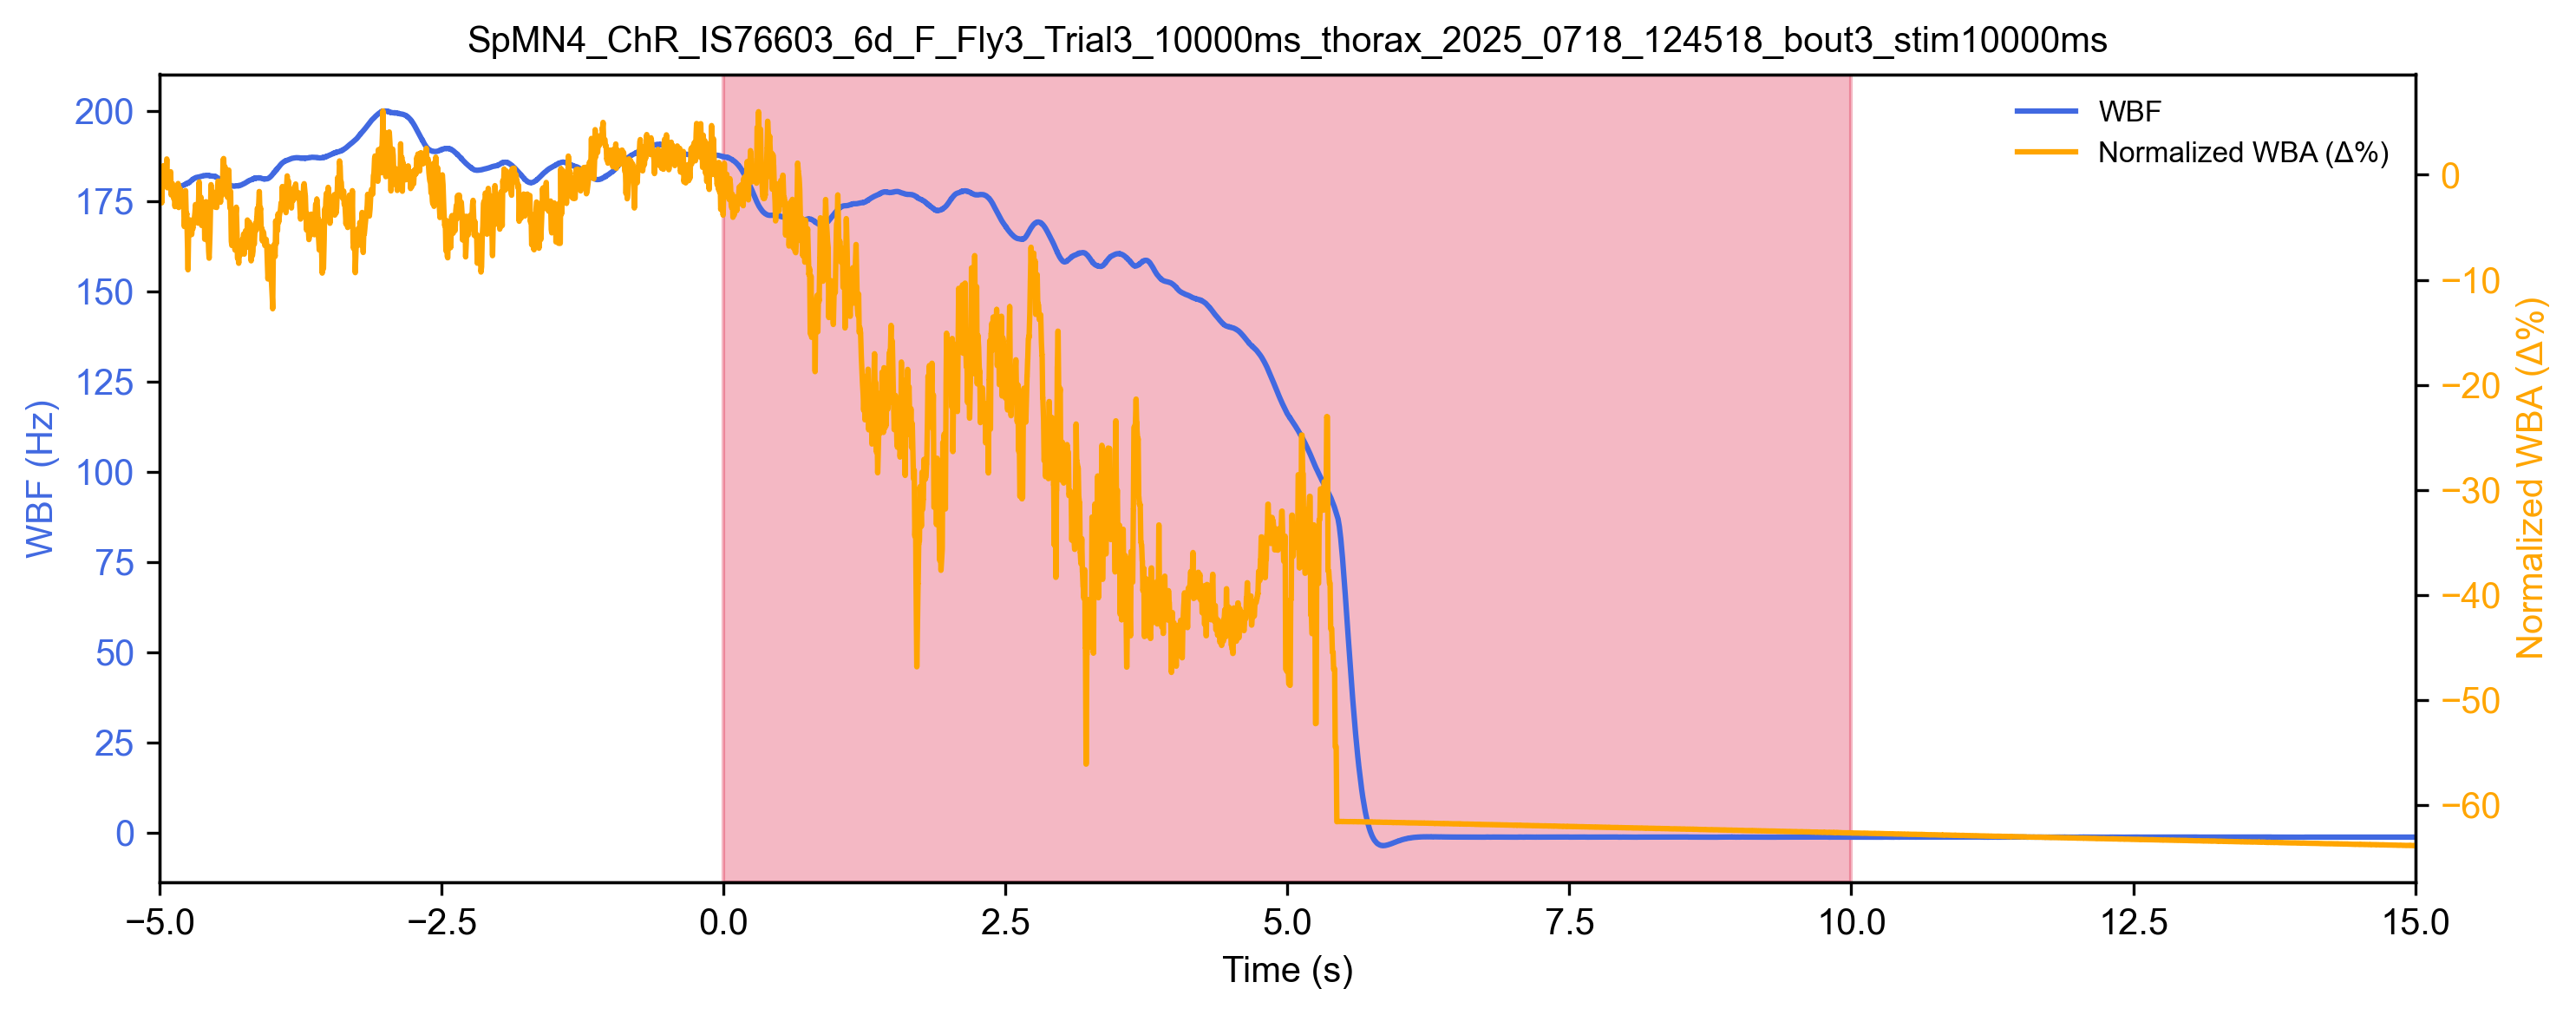

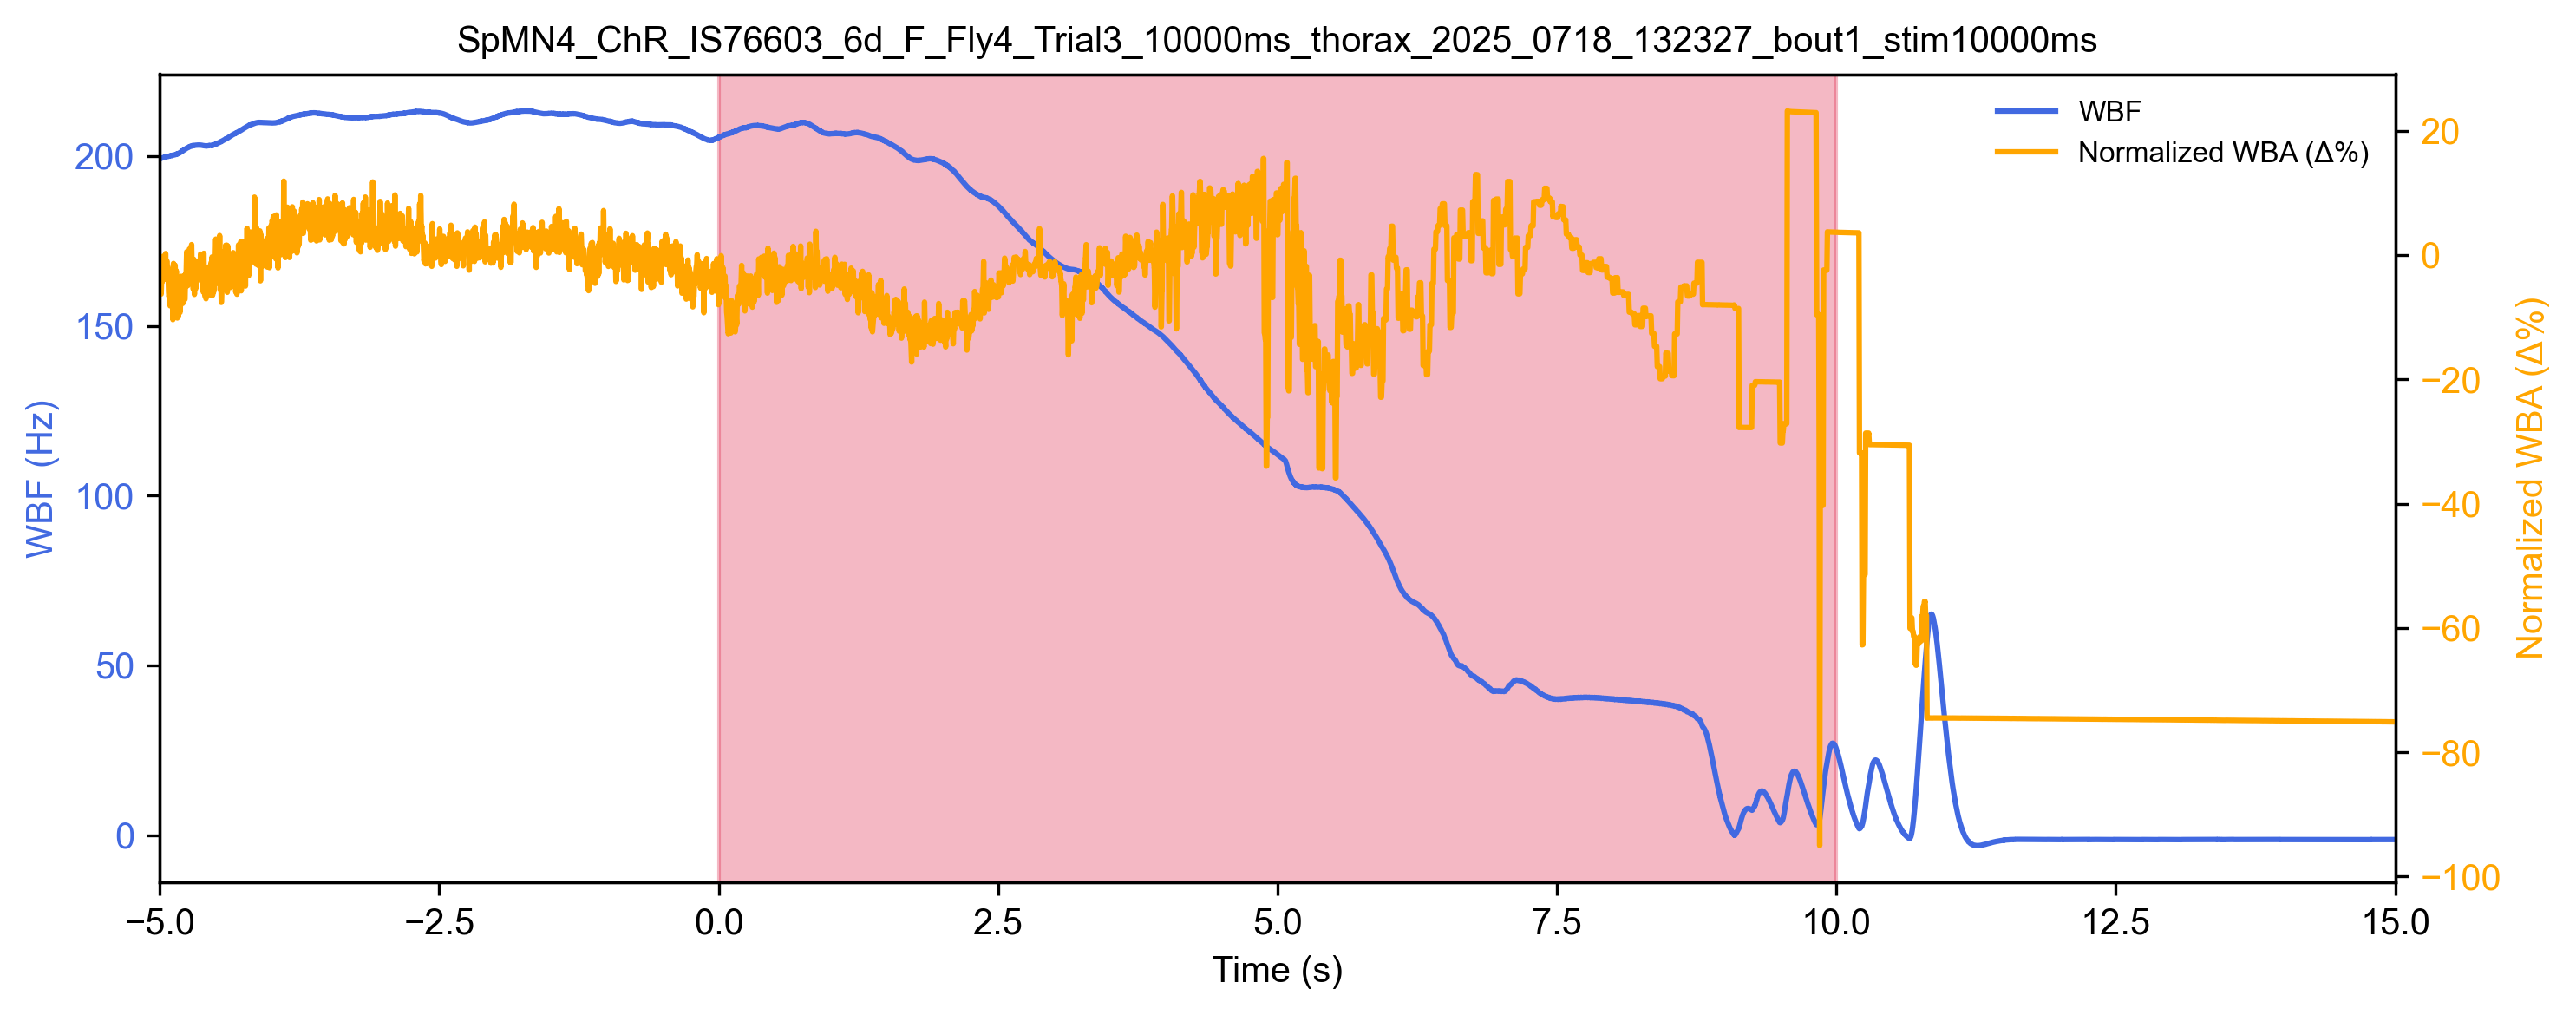

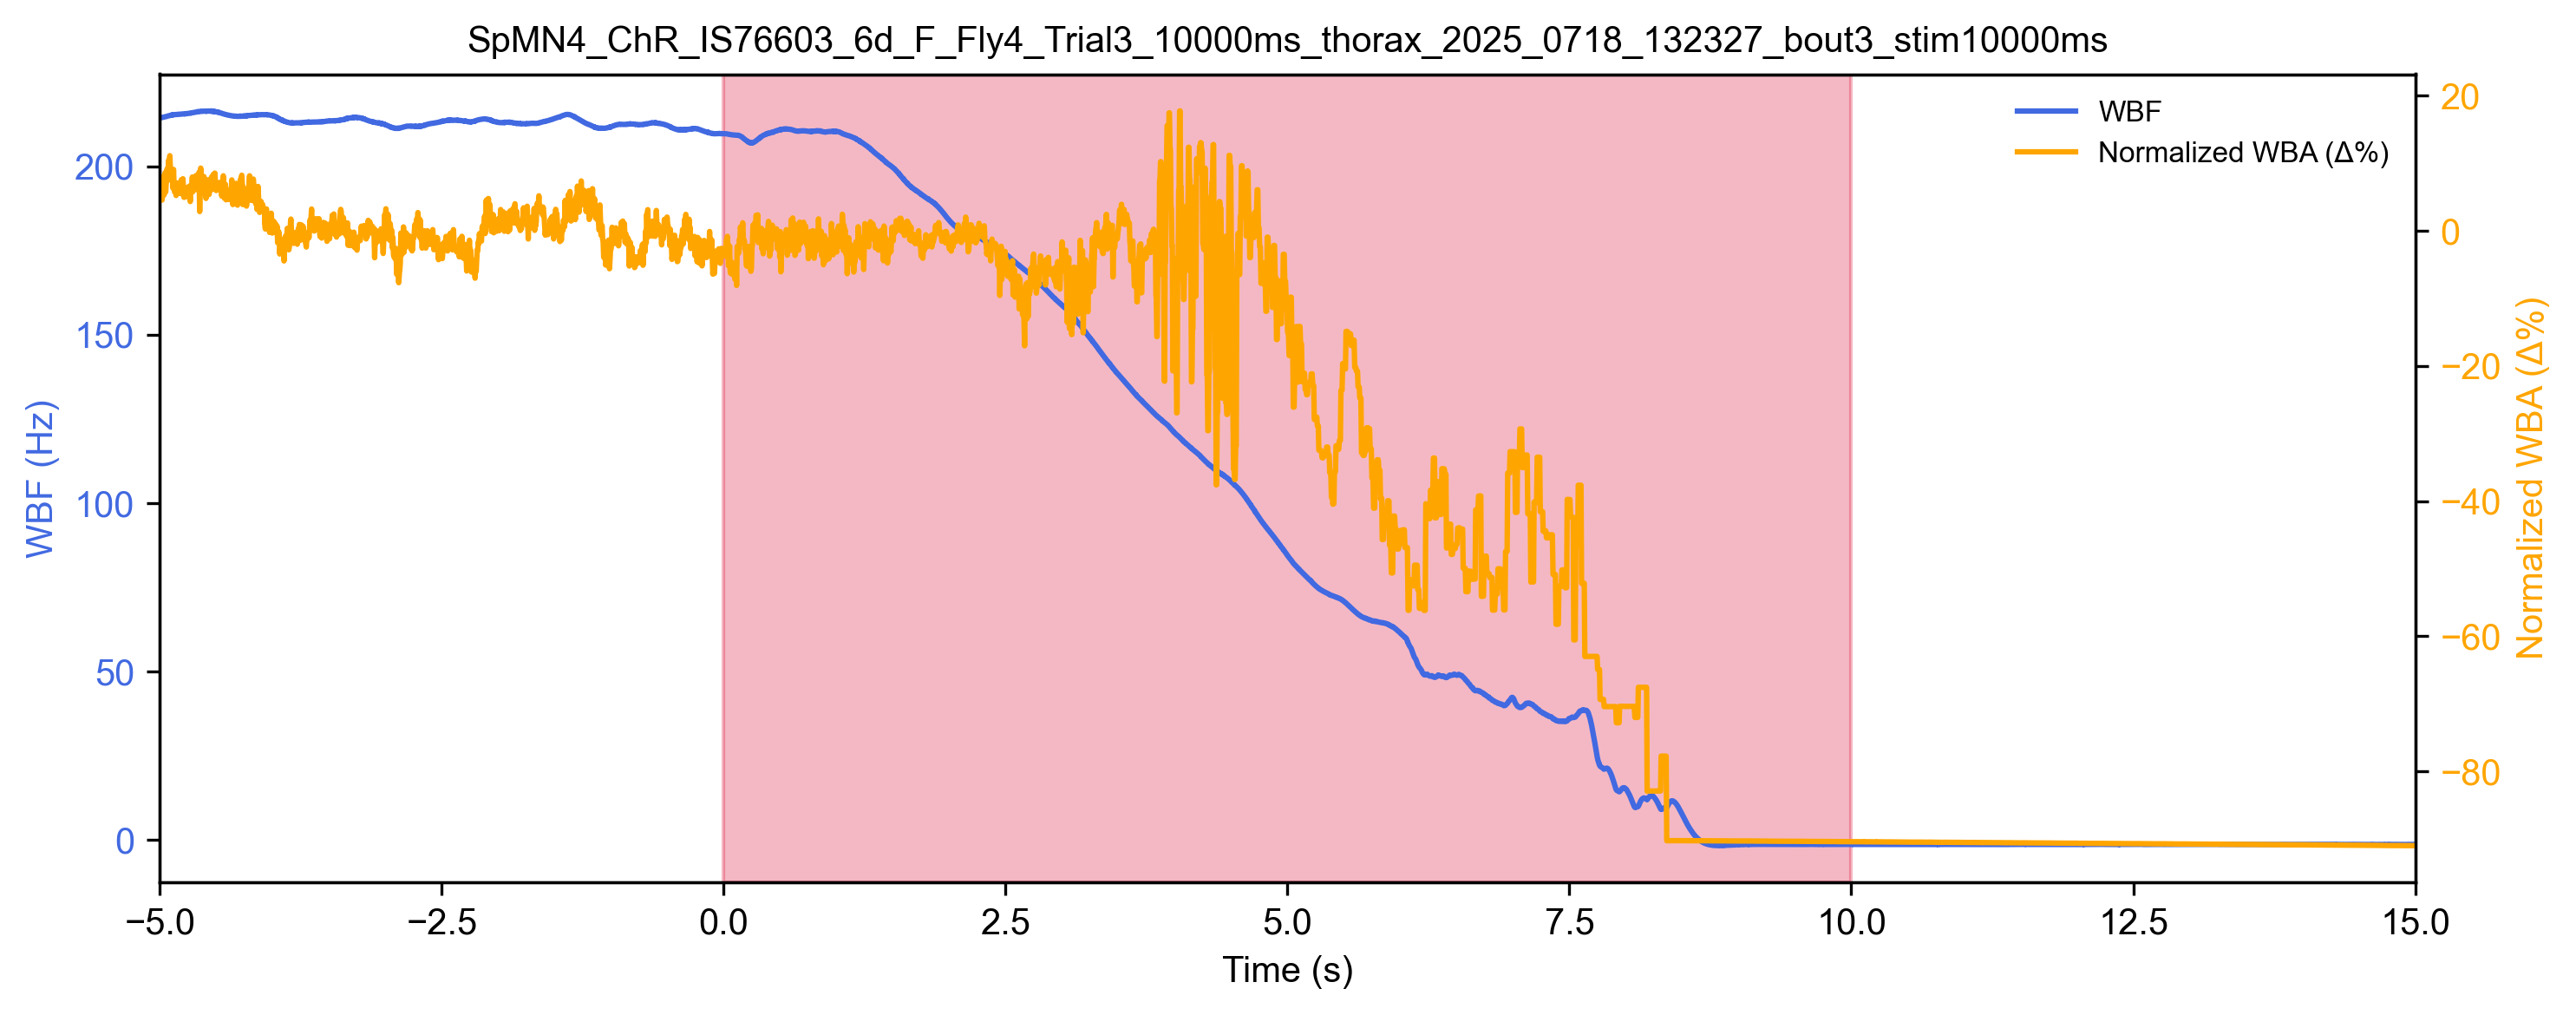

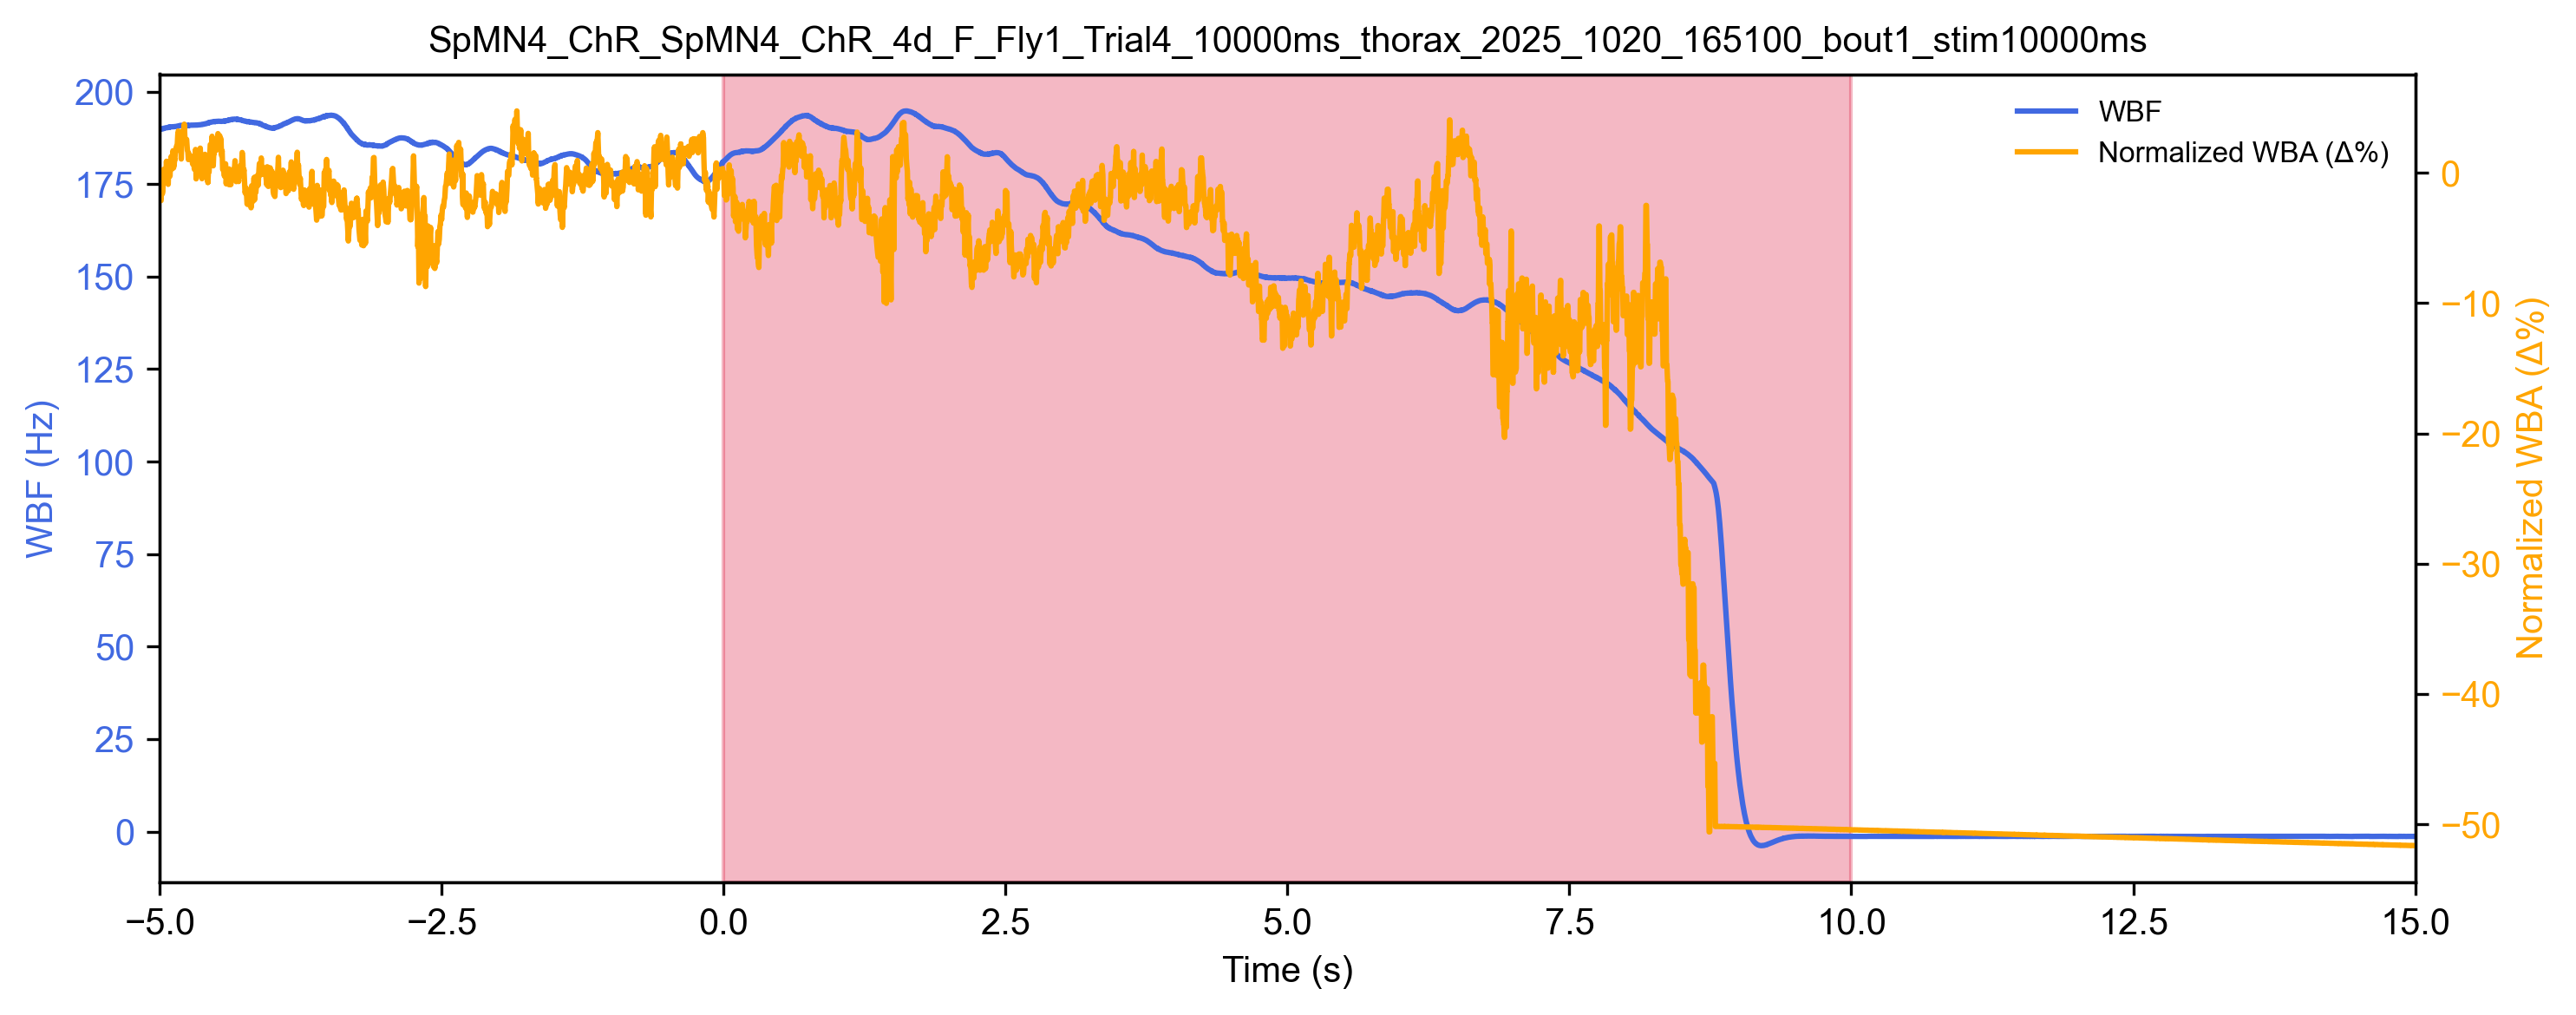

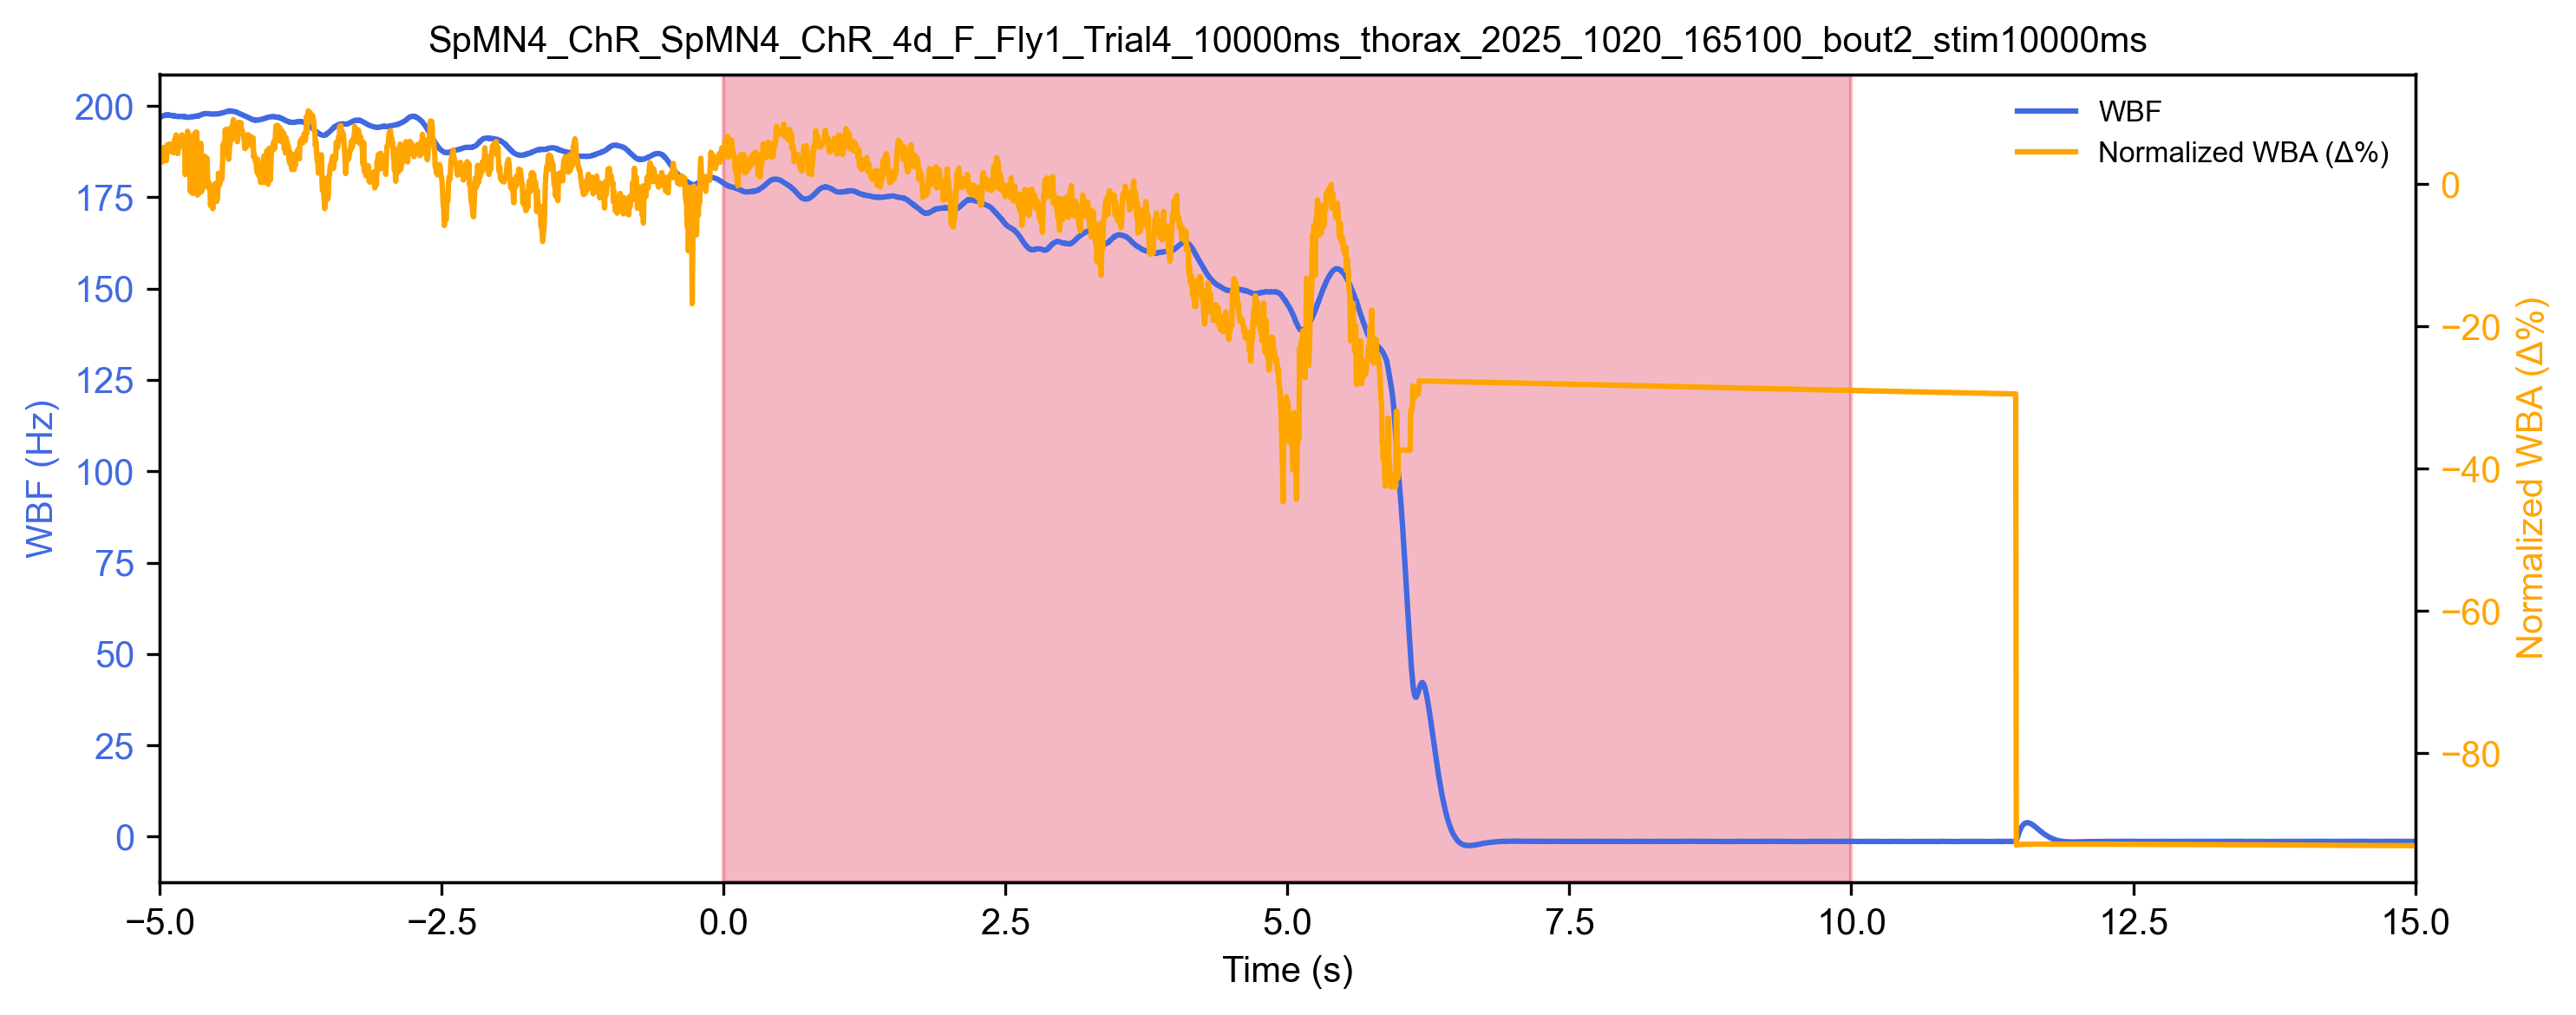

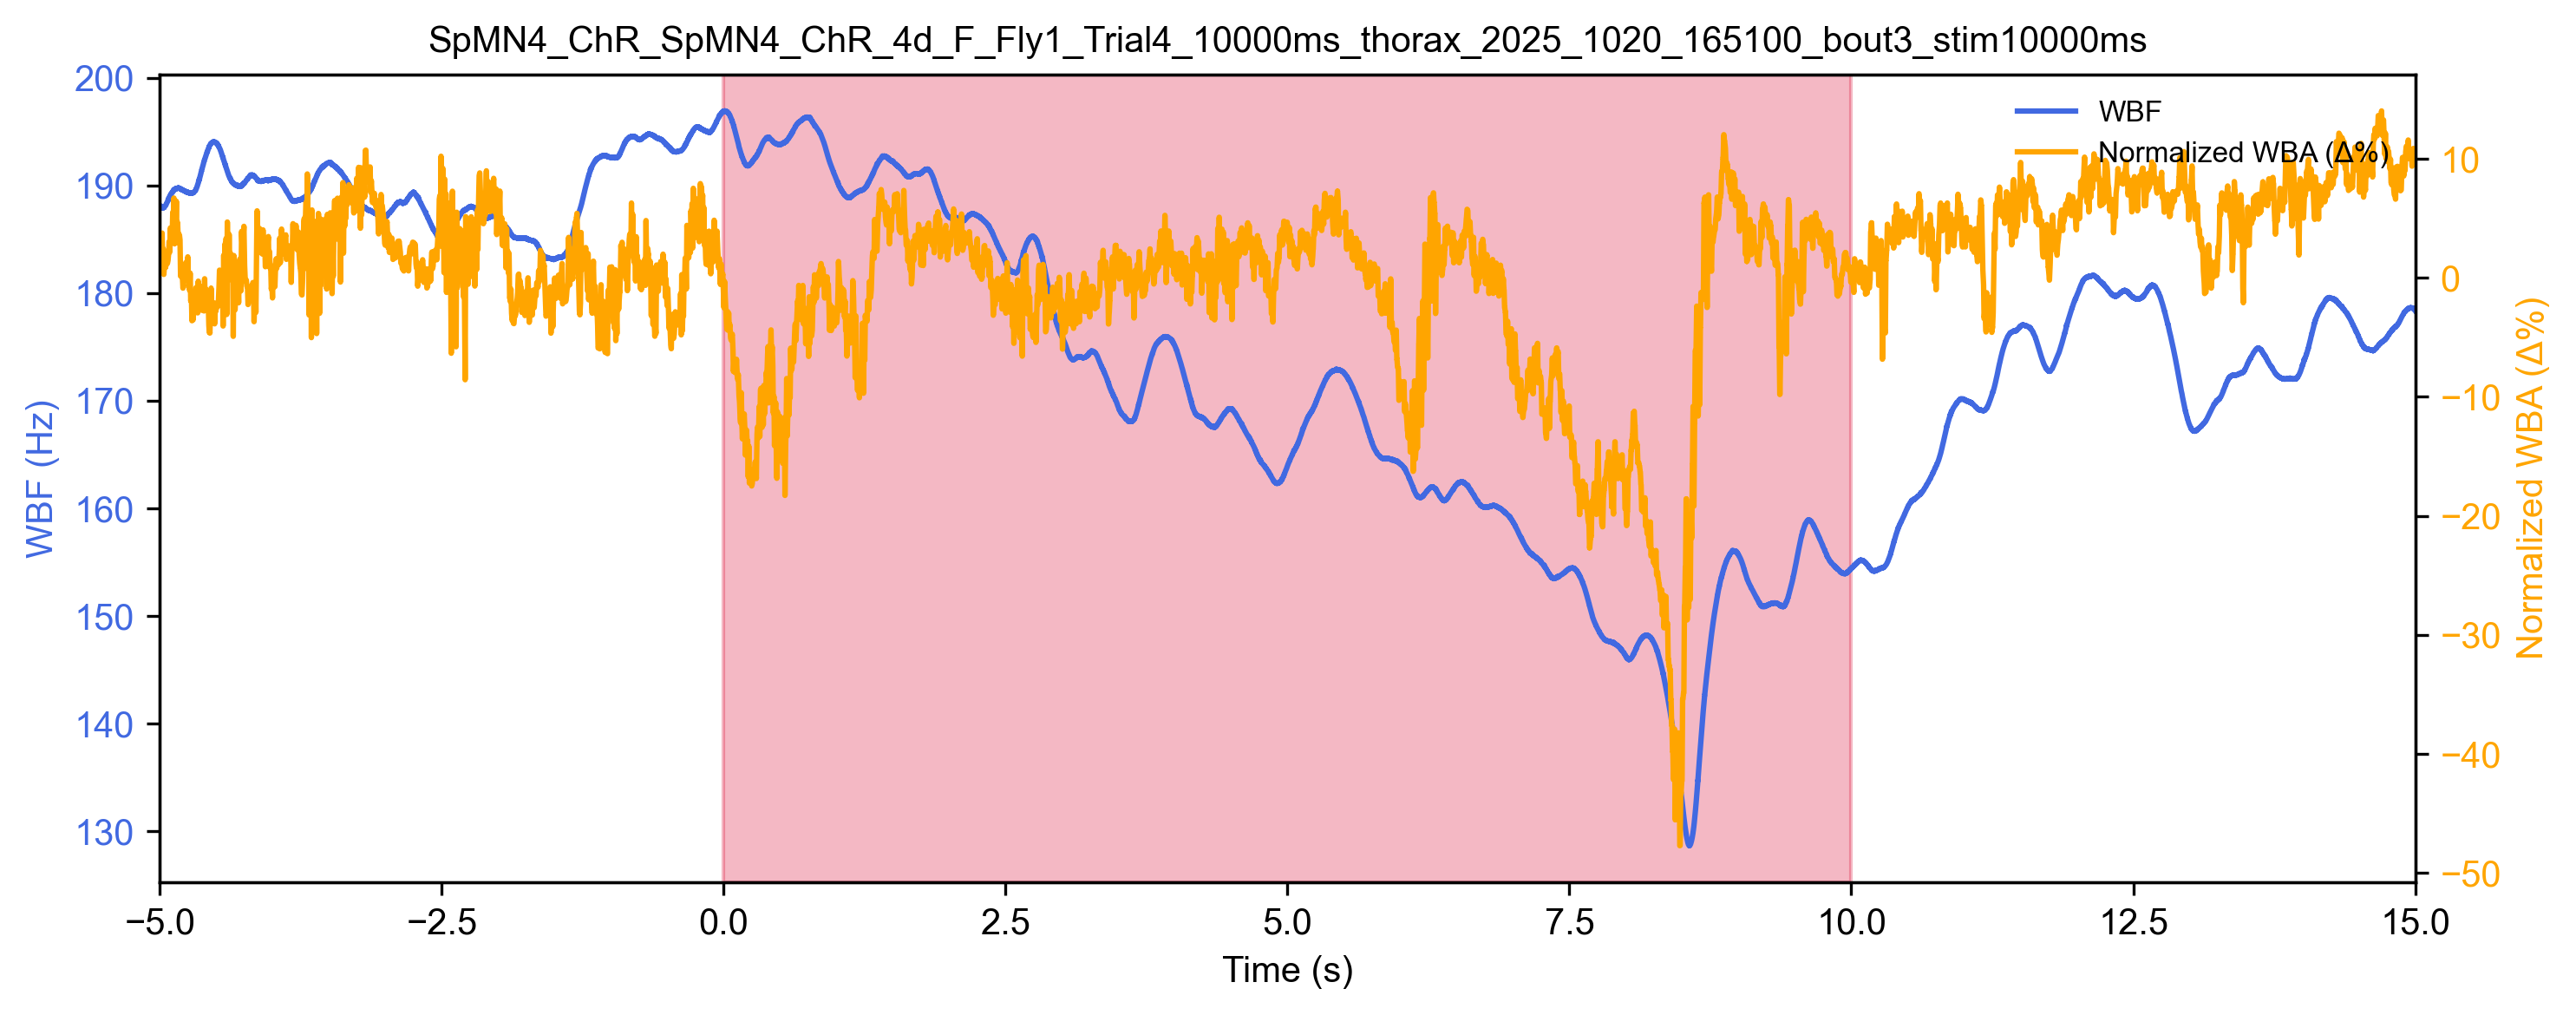

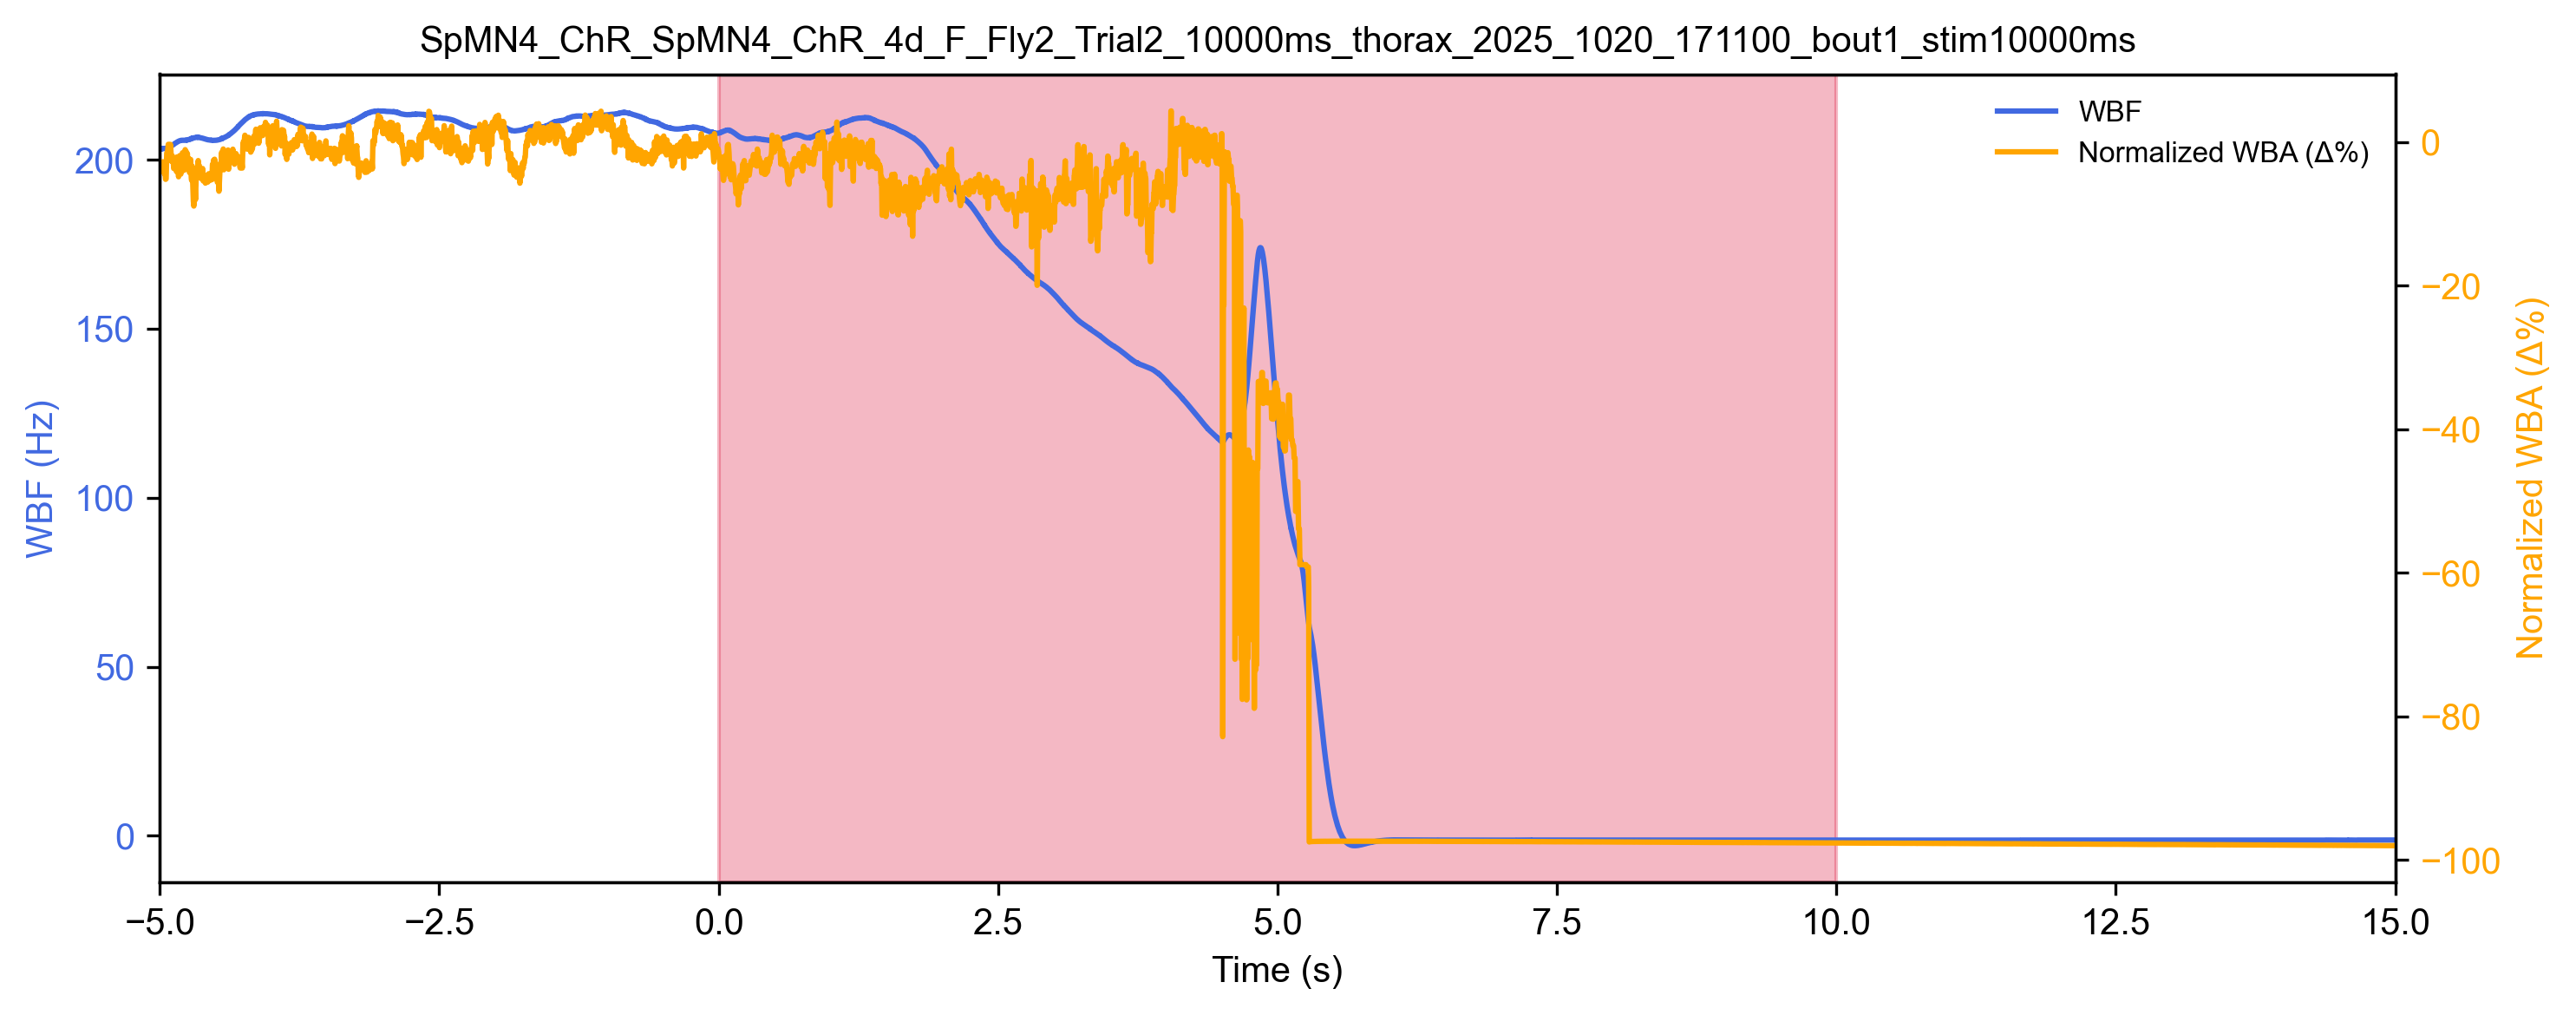

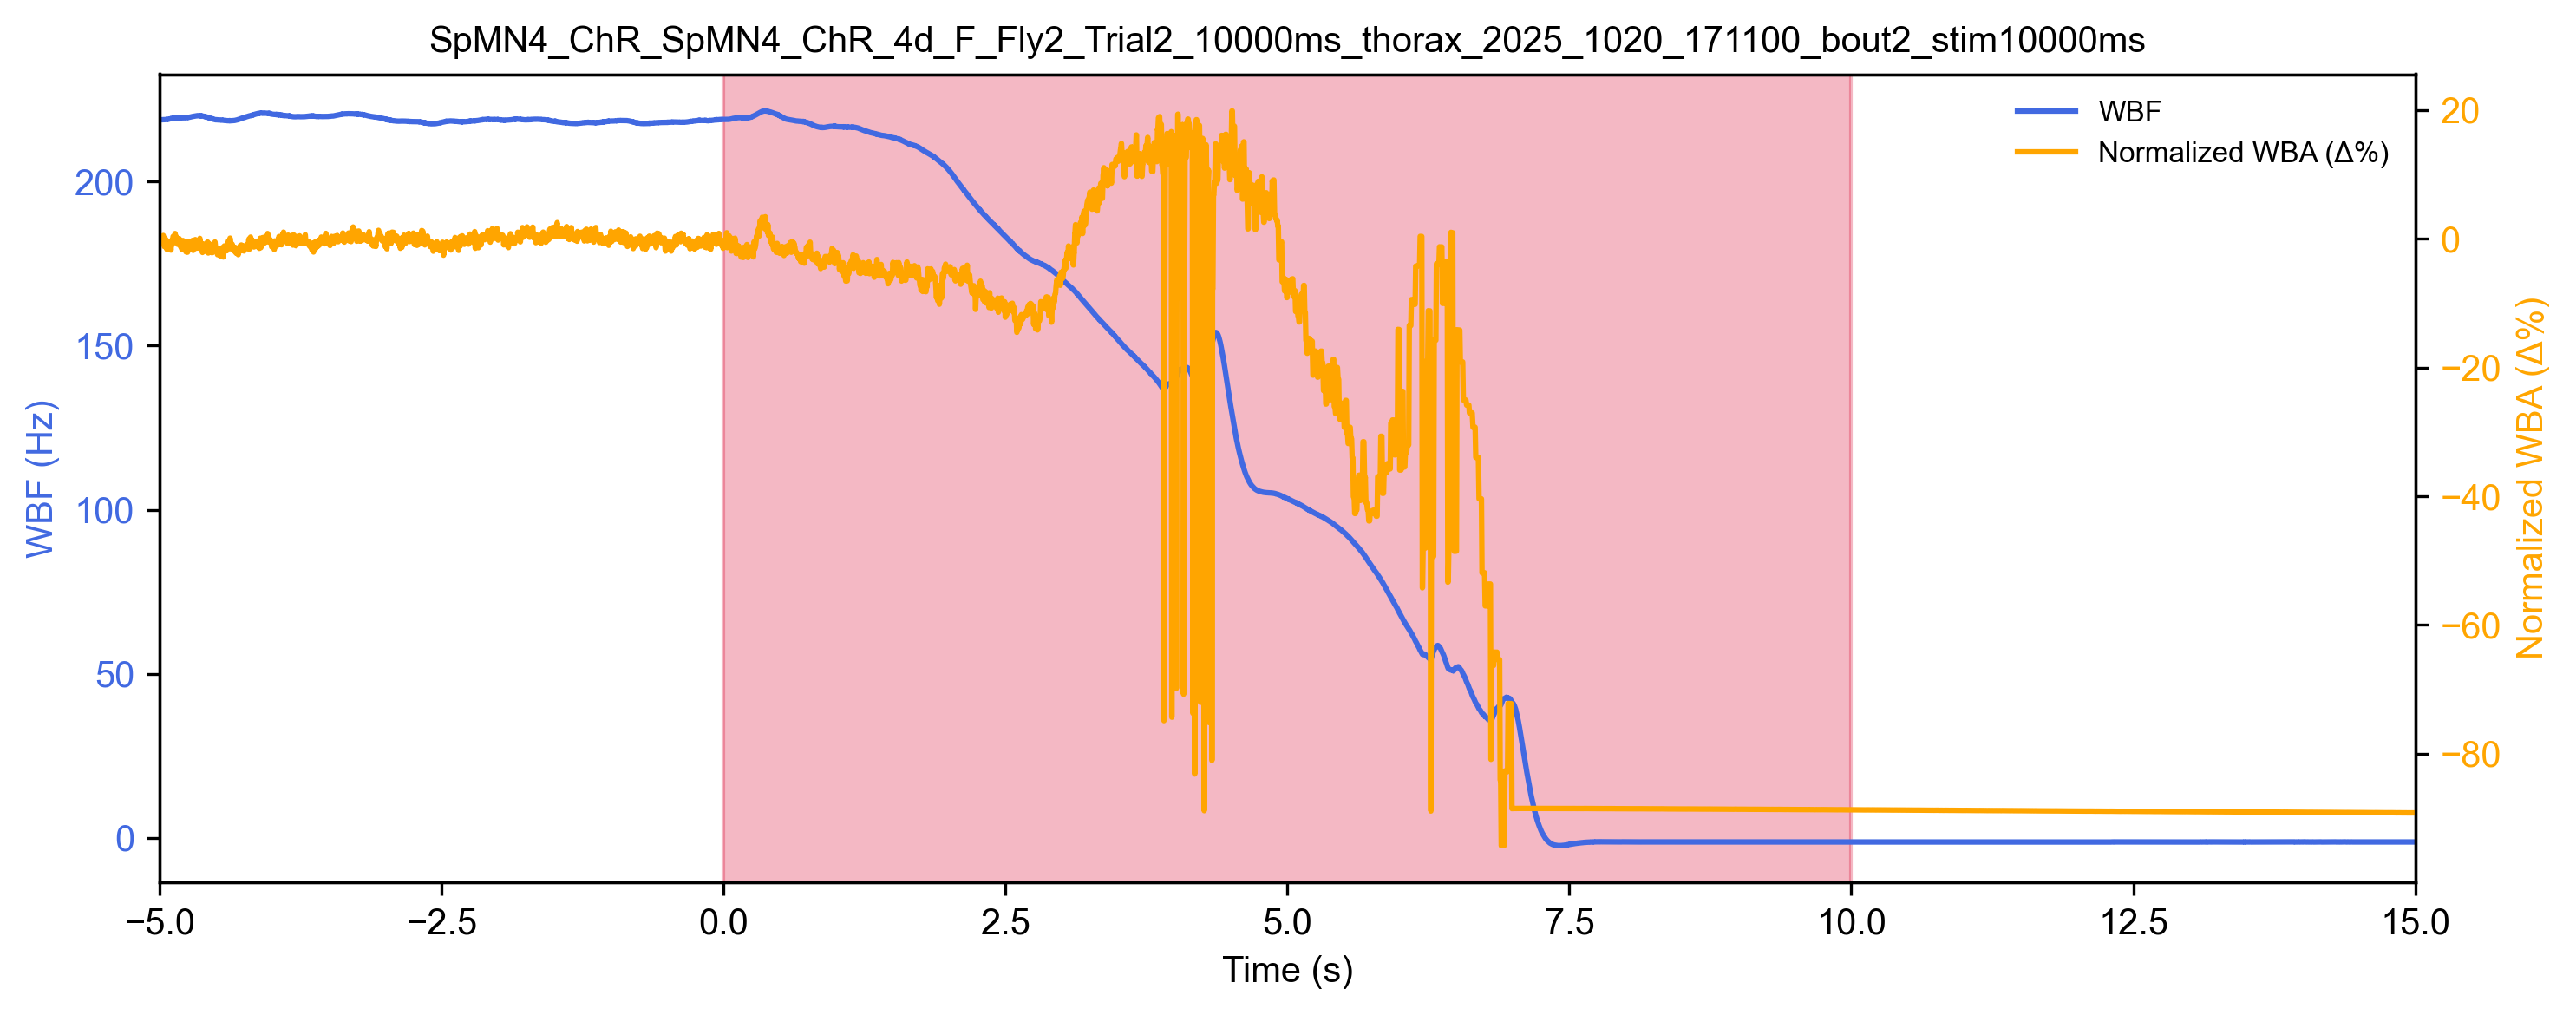

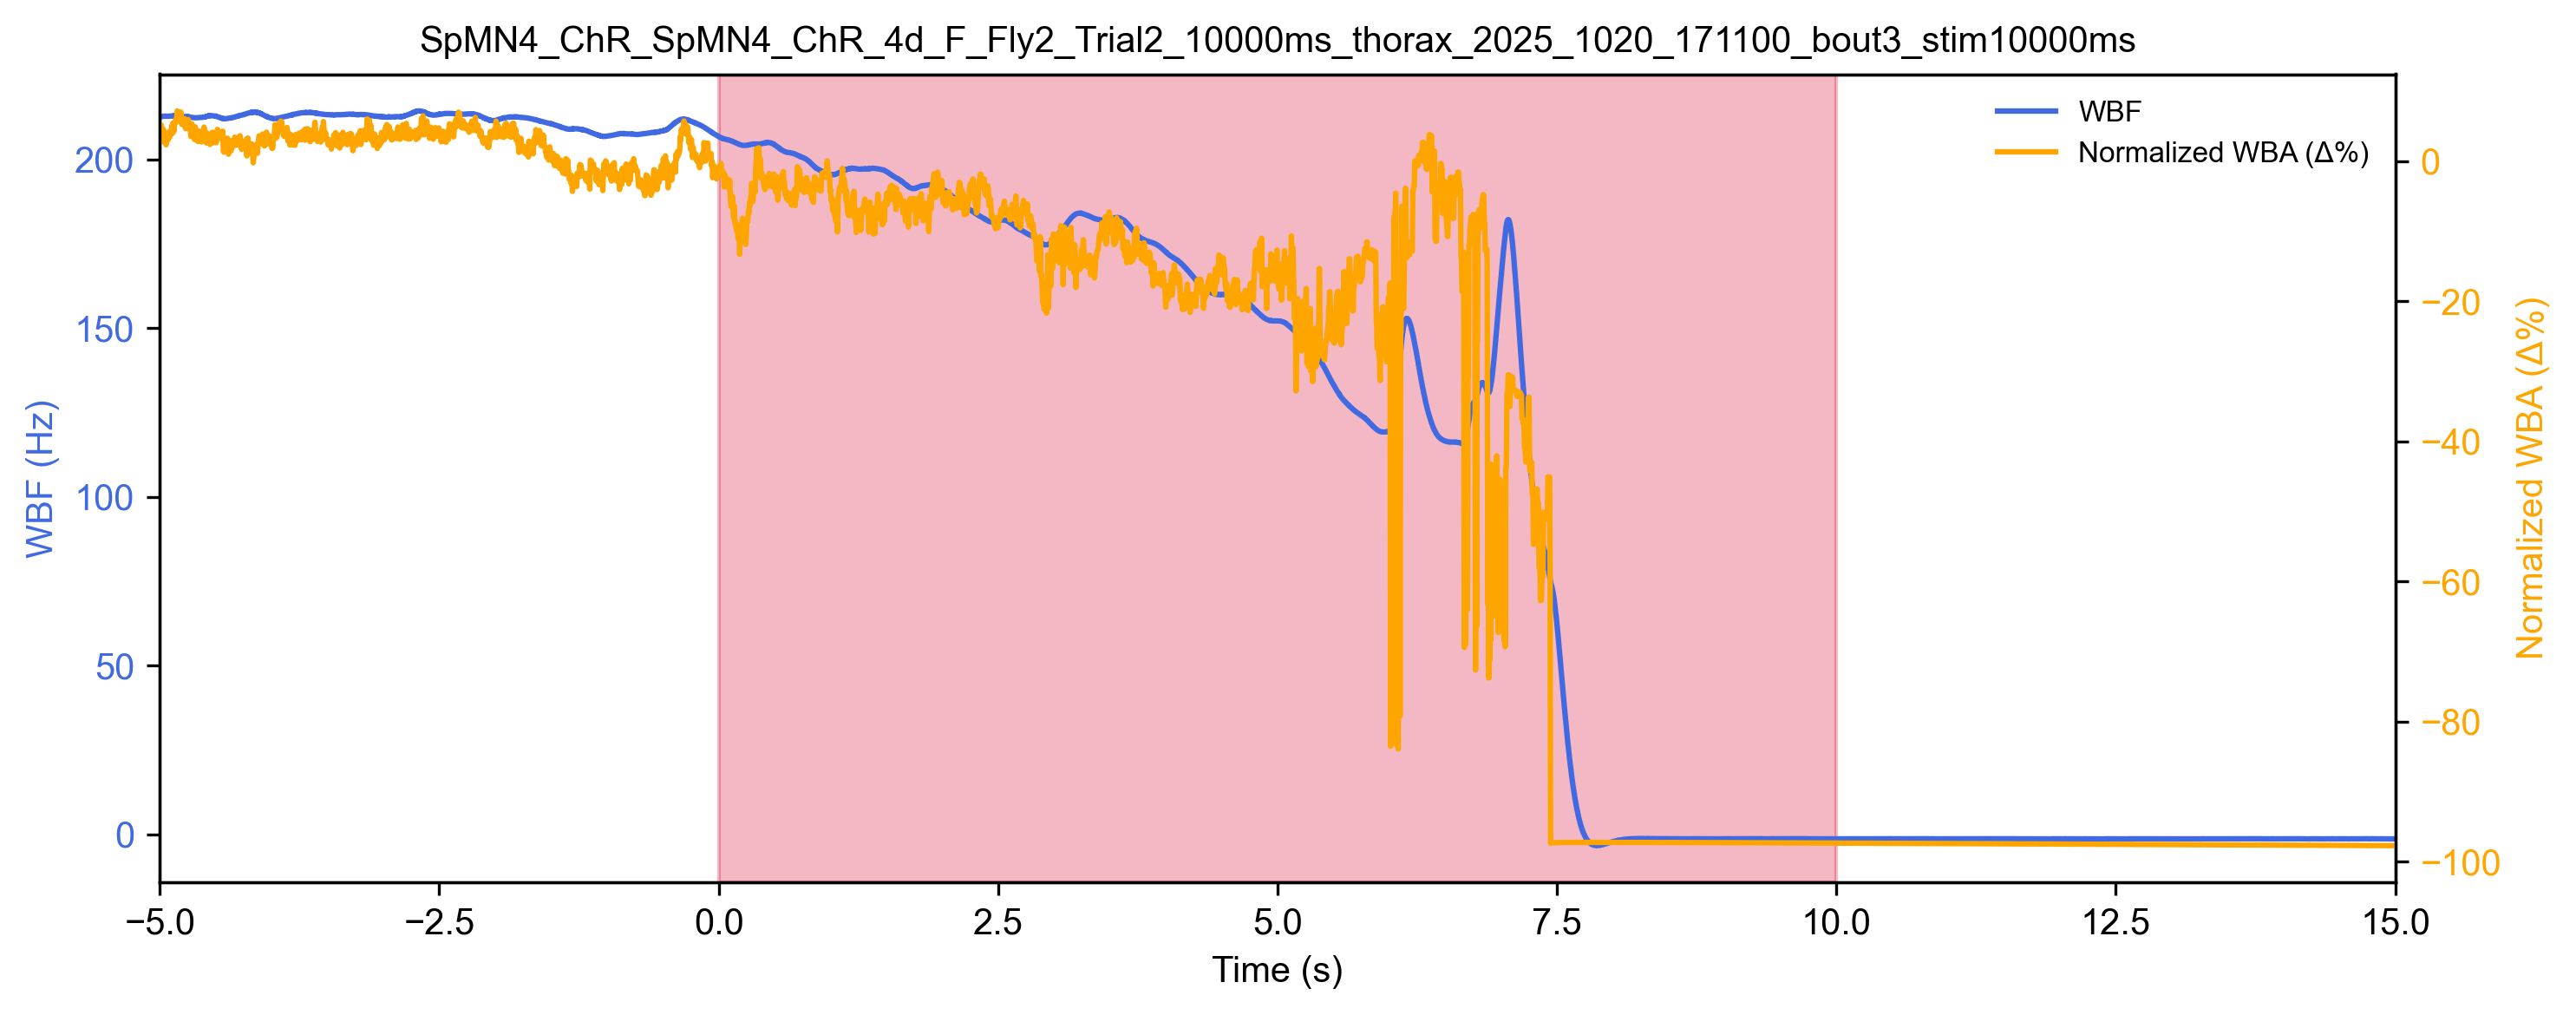


Saved 22 bout SVGs to /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/3_SpMN/SpMN4_ChR_10s_noPhantom/per_bout_plots


In [36]:
# ===== Cell 2b: Display & save individual bout traces as SVG =====
# One SVG per bout, dual-axis (WBF left, Normalized WBA Δ% right), stim shaded.
# Saved to OUTPUT_DIR/per_bout_plots/.
PLOTS_DIR = os.path.join(OUTPUT_DIR, "per_bout_plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

stim_color = get_stim_color(INPUT_DIR)
bout_csvs = sorted(glob.glob(os.path.join(BOUTS_DIR, "*.csv")))
print(f"Plotting {len(bout_csvs)} individual bouts -> {PLOTS_DIR}")

for csv_path in bout_csvs:
    df = pd.read_csv(csv_path)
    t = df['Time (s)'].values

    baseline_mask = (t >= -2) & (t < 0)
    if not baseline_mask.any():
        print(f"  Skipping {os.path.basename(csv_path)}: no baseline window")
        continue

    wbf = df['Wingbeat Frequency'].values
    base_wba = df.loc[baseline_mask, 'Wing Beat Amplitude'].mean()
    nwba_delta = (df['Wing Beat Amplitude'].values / base_wba * 100 - 100) if base_wba != 0 else np.full_like(t, np.nan)

    fig, ax1 = plt.subplots(figsize=(10, 4), dpi=300)
    ax1.plot(t, wbf, color='royalblue', label='WBF')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('WBF (Hz)', color='royalblue')
    ax1.tick_params(axis='y', labelcolor='royalblue')
    ax1.set_xlim(-5, STIM_DURATION_S + 5)

    ax2 = ax1.twinx()
    ax2.plot(t, nwba_delta, color='orange', label='Normalized WBA (Δ%)')
    ax2.set_ylabel('Normalized WBA (Δ%)', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    ymin, ymax = ax1.get_ylim()
    ax1.fill_between([0, STIM_DURATION_S], ymin, ymax, color=stim_color, alpha=0.3, zorder=0)
    ax1.set_ylim(ymin, ymax)

    bout_name = os.path.splitext(os.path.basename(csv_path))[0]
    ax1.set_title(bout_name, fontsize=10)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False, fontsize=8)

    out_svg = os.path.join(PLOTS_DIR, f"{bout_name}.svg")
    fig.tight_layout()
    fig.savefig(out_svg, format='svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

print(f"\nSaved {len(bout_csvs)} bout SVGs to {PLOTS_DIR}")


**Cell 3 — Aggregate to an across-fly summary.** Hierarchical averaging: each `.mat` is one fly, so it first averages that fly's bouts (interpolated onto the canonical time axis), then averages across flies into mean ± SEM (denominator = N flies) for WBF, ΔWBF, WBA and Normalized WBA. Writes `summary_across_bouts_<ms>ms.csv`.

**Cell 3 —— 汇总为跨果蝇的汇总表。** 分层平均：每个 `.mat` 即一只果蝇，先对该蝇的各片段求平均（插值到标准时间轴），再跨果蝇求均值 ± SEM（分母 = 果蝇数 N），涵盖 WBF、ΔWBF、WBA 与归一化 WBA。写出 `summary_across_bouts_<毫秒>ms.csv`。

In [37]:
# ===== Cell 3: Aggregate per-bout CSVs -> per-fly means -> across-fly summary =====
# Hierarchical: within fly (avg bouts) -> across flies (mean ± SEM, N = N flies).
# Each .mat file == one fly; per-bout CSVs are named "{prefix}_bout{N}_stim{ms}ms.csv".
import re

bout_csvs = sorted(glob.glob(os.path.join(BOUTS_DIR, "*.csv")))
print(f"Aggregating {len(bout_csvs)} per-bout CSVs...")
if len(bout_csvs) == 0:
    raise RuntimeError(f"No per-bout CSVs found in {BOUTS_DIR}; run Cell 2 first.")

def fly_id_from_csv(path):
    name = os.path.basename(path)
    # strip "_bout{N}_stim{...}.csv" suffix
    return re.sub(r"_bout\d+_stim[^_]+\.csv$", "", name)

# Group bouts by fly
bouts_by_fly = {}
for p in bout_csvs:
    bouts_by_fly.setdefault(fly_id_from_csv(p), []).append(p)
print(f"Found {len(bouts_by_fly)} flies; bouts per fly: "
      f"{ {f: len(b) for f, b in bouts_by_fly.items()} }")

def interp_to_canonical(t, y):
    f = interpolate.interp1d(t, y, kind='linear', bounds_error=False, fill_value=np.nan)
    return f(CANONICAL_T)

# Step 1: per-fly mean trace for each signal
per_fly_wbf, per_fly_wba = [], []
per_fly_dwbf, per_fly_nwba = [], []
fly_ids_used = []

for fly_id, csv_paths in bouts_by_fly.items():
    wbf_bouts, wba_bouts, dwbf_bouts, nwba_bouts = [], [], [], []
    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)
        t = df['Time (s)'].values
        baseline_mask = (t >= -2) & (t < 0)
        if not baseline_mask.any():
            print(f"  Skipping {os.path.basename(csv_path)}: no baseline samples")
            continue
        base_wbf = df.loc[baseline_mask, 'Wingbeat Frequency'].mean()
        base_wba = df.loc[baseline_mask, 'Wing Beat Amplitude'].mean()
        delta_wbf = df['Wingbeat Frequency'].values - base_wbf
        norm_wba = (df['Wing Beat Amplitude'].values / base_wba * 100
                    if base_wba != 0 else np.full_like(t, np.nan, dtype=float))
        wbf_bouts.append(interp_to_canonical(t, df['Wingbeat Frequency'].values))
        wba_bouts.append(interp_to_canonical(t, df['Wing Beat Amplitude'].values))
        dwbf_bouts.append(interp_to_canonical(t, delta_wbf))
        nwba_bouts.append(interp_to_canonical(t, norm_wba))
    if not wbf_bouts:
        print(f"  Skipping fly {fly_id}: no usable bouts")
        continue
    # within-fly mean (nan-safe in case any future masking introduces NaNs)
    per_fly_wbf.append(np.nanmean(np.vstack(wbf_bouts), axis=0))
    per_fly_wba.append(np.nanmean(np.vstack(wba_bouts), axis=0))
    per_fly_dwbf.append(np.nanmean(np.vstack(dwbf_bouts), axis=0))
    per_fly_nwba.append(np.nanmean(np.vstack(nwba_bouts), axis=0))
    fly_ids_used.append(fly_id)

n_flies = len(fly_ids_used)
print(f"Per-fly stacks built for {n_flies} flies.")

# Step 2: across-fly mean & SEM (denominator = N flies)
def mean_sem(stack):
    arr = np.vstack(stack)
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0) / np.sqrt(arr.shape[0])

mean_wbf,  sem_wbf  = mean_sem(per_fly_wbf)
mean_wba,  sem_wba  = mean_sem(per_fly_wba)
mean_dwbf, sem_dwbf = mean_sem(per_fly_dwbf)
mean_nwba, sem_nwba = mean_sem(per_fly_nwba)

opto_mask = np.zeros(BOUT_LEN)
opto_mask[int(PRE * FS):int((PRE + STIM_DURATION_S) * FS)] = 1

summary_df = pd.DataFrame({
    'Time (s)': CANONICAL_T,
    'Mean Wingbeat Frequency': mean_wbf,
    'SEM Wingbeat Frequency': sem_wbf,
    'Mean Delta Wingbeat Frequency': mean_dwbf,
    'SEM Delta Wingbeat Frequency': sem_dwbf,
    'Mean Wing Beat Amplitude': mean_wba,
    'SEM Wing Beat Amplitude': sem_wba,
    'Mean Normalized Wing Beat Amplitude': mean_nwba,
    'SEM Normalized Wing Beat Amplitude': sem_nwba,
    'Opto Stimulus': opto_mask,
})

stim_ms = int(round(STIM_DURATION_S * 1000))
summary_csv = os.path.join(OUTPUT_DIR, f"summary_across_bouts_{stim_ms}ms.csv")
summary_df.to_csv(summary_csv, index=False)
print(f"Wrote summary CSV (n={n_flies} flies): {summary_csv}")
n_bouts = n_flies  # legend label compatibility for Cell 4
summary_df.head()


Aggregating 22 per-bout CSVs...
Found 8 flies; bouts per fly: {'SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly3_Trial6_10000ms_66_thorax_2025_1226_162645': 3, 'SpMN4_ChR_EMG_VT29591_R47A08_6d_F_Fly1_Trial5_10000ms_2025_0321_115218': 2, 'SpMN4_ChR_IS76603_6d_F_Fly1_Trial3_10000ms_thorax_2025_0718_113814': 3, 'SpMN4_ChR_IS76603_6d_F_Fly2_Trial3_10000ms_thorax_2025_0718_120753': 3, 'SpMN4_ChR_IS76603_6d_F_Fly3_Trial3_10000ms_thorax_2025_0718_124518': 3, 'SpMN4_ChR_IS76603_6d_F_Fly4_Trial3_10000ms_thorax_2025_0718_132327': 2, 'SpMN4_ChR_SpMN4_ChR_4d_F_Fly1_Trial4_10000ms_thorax_2025_1020_165100': 3, 'SpMN4_ChR_SpMN4_ChR_4d_F_Fly2_Trial2_10000ms_thorax_2025_1020_171100': 3}


/var/folders/24/4641y0j978d462l0ntzxn_l40000gn/T/ipykernel_41031/2214102977.py:54: RuntimeWarning: Mean of empty slice
  per_fly_wbf.append(np.nanmean(np.vstack(wbf_bouts), axis=0))
/var/folders/24/4641y0j978d462l0ntzxn_l40000gn/T/ipykernel_41031/2214102977.py:55: RuntimeWarning: Mean of empty slice
  per_fly_wba.append(np.nanmean(np.vstack(wba_bouts), axis=0))
/var/folders/24/4641y0j978d462l0ntzxn_l40000gn/T/ipykernel_41031/2214102977.py:56: RuntimeWarning: Mean of empty slice
  per_fly_dwbf.append(np.nanmean(np.vstack(dwbf_bouts), axis=0))
/var/folders/24/4641y0j978d462l0ntzxn_l40000gn/T/ipykernel_41031/2214102977.py:57: RuntimeWarning: Mean of empty slice
  per_fly_nwba.append(np.nanmean(np.vstack(nwba_bouts), axis=0))
/var/folders/24/4641y0j978d462l0ntzxn_l40000gn/T/ipykernel_41031/2214102977.py:54: RuntimeWarning: Mean of empty slice
  per_fly_wbf.append(np.nanmean(np.vstack(wbf_bouts), axis=0))
/var/folders/24/4641y0j978d462l0ntzxn_l40000gn/T/ipykernel_41031/2214102977.py:55: Run

Per-fly stacks built for 8 flies.
Wrote summary CSV (n=8 flies): /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/3_SpMN/SpMN4_ChR_10s_noPhantom/summary_across_bouts_10000ms.csv


,Time (s),Mean Wingbeat Frequency,SEM Wingbeat Frequency,Mean Delta Wingbeat Frequency,SEM Delta Wingbeat Frequency,Mean Wing Beat Amplitude,SEM Wing Beat Amplitude,Mean Normalized Wing Beat Amplitude,SEM Normalized Wing Beat Amplitude,Opto Stimulus
0,-5.00000,199.854146,4.422671,0.517616,1.035453,3.908841,0.171039,99.203015,0.580081,0.0
1,-4.99995,199.853906,4.422678,0.517377,1.035407,3.908973,0.171103,99.206009,0.576620,0.0
2,-4.99990,199.854420,4.422726,0.517890,1.035256,3.909023,0.171127,99.207230,0.572359,0.0
3,-4.99985,199.854947,4.422709,0.518418,1.035298,3.909139,0.171182,99.209904,0.568840,0.0
4,-4.99980,199.855098,4.422817,0.518568,1.035262,3.909295,0.171245,99.213423,0.565006,0.0


**Cell 4 — Summary SVG.** Plots the across-fly figure in the Step-4-no-EMG style: faint individual per-bout WBF traces behind the thick WBF mean ± SEM (left axis) and Normalized WBA Δ% (right axis), with the stimulus window shaded. Saved as `summary_across_bouts_<ms>ms.svg`.

**Cell 4 —— 汇总 SVG。** 以“第四步无 EMG 版”的风格绘制跨果蝇图：粗线的 WBF 均值 ± SEM（左轴）后方衬以浅色的各片段 WBF 单条曲线，外加归一化 WBA Δ%（右轴），并对刺激窗加阴影。保存为 `summary_across_bouts_<毫秒>ms.svg`。

Stim shading color: crimson
Overlay: 22 individual bouts
Wrote SVG: /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/Phantom_video_analysis/3_SpMN/SpMN4_ChR_10s_noPhantom/summary_across_bouts_10000ms.svg


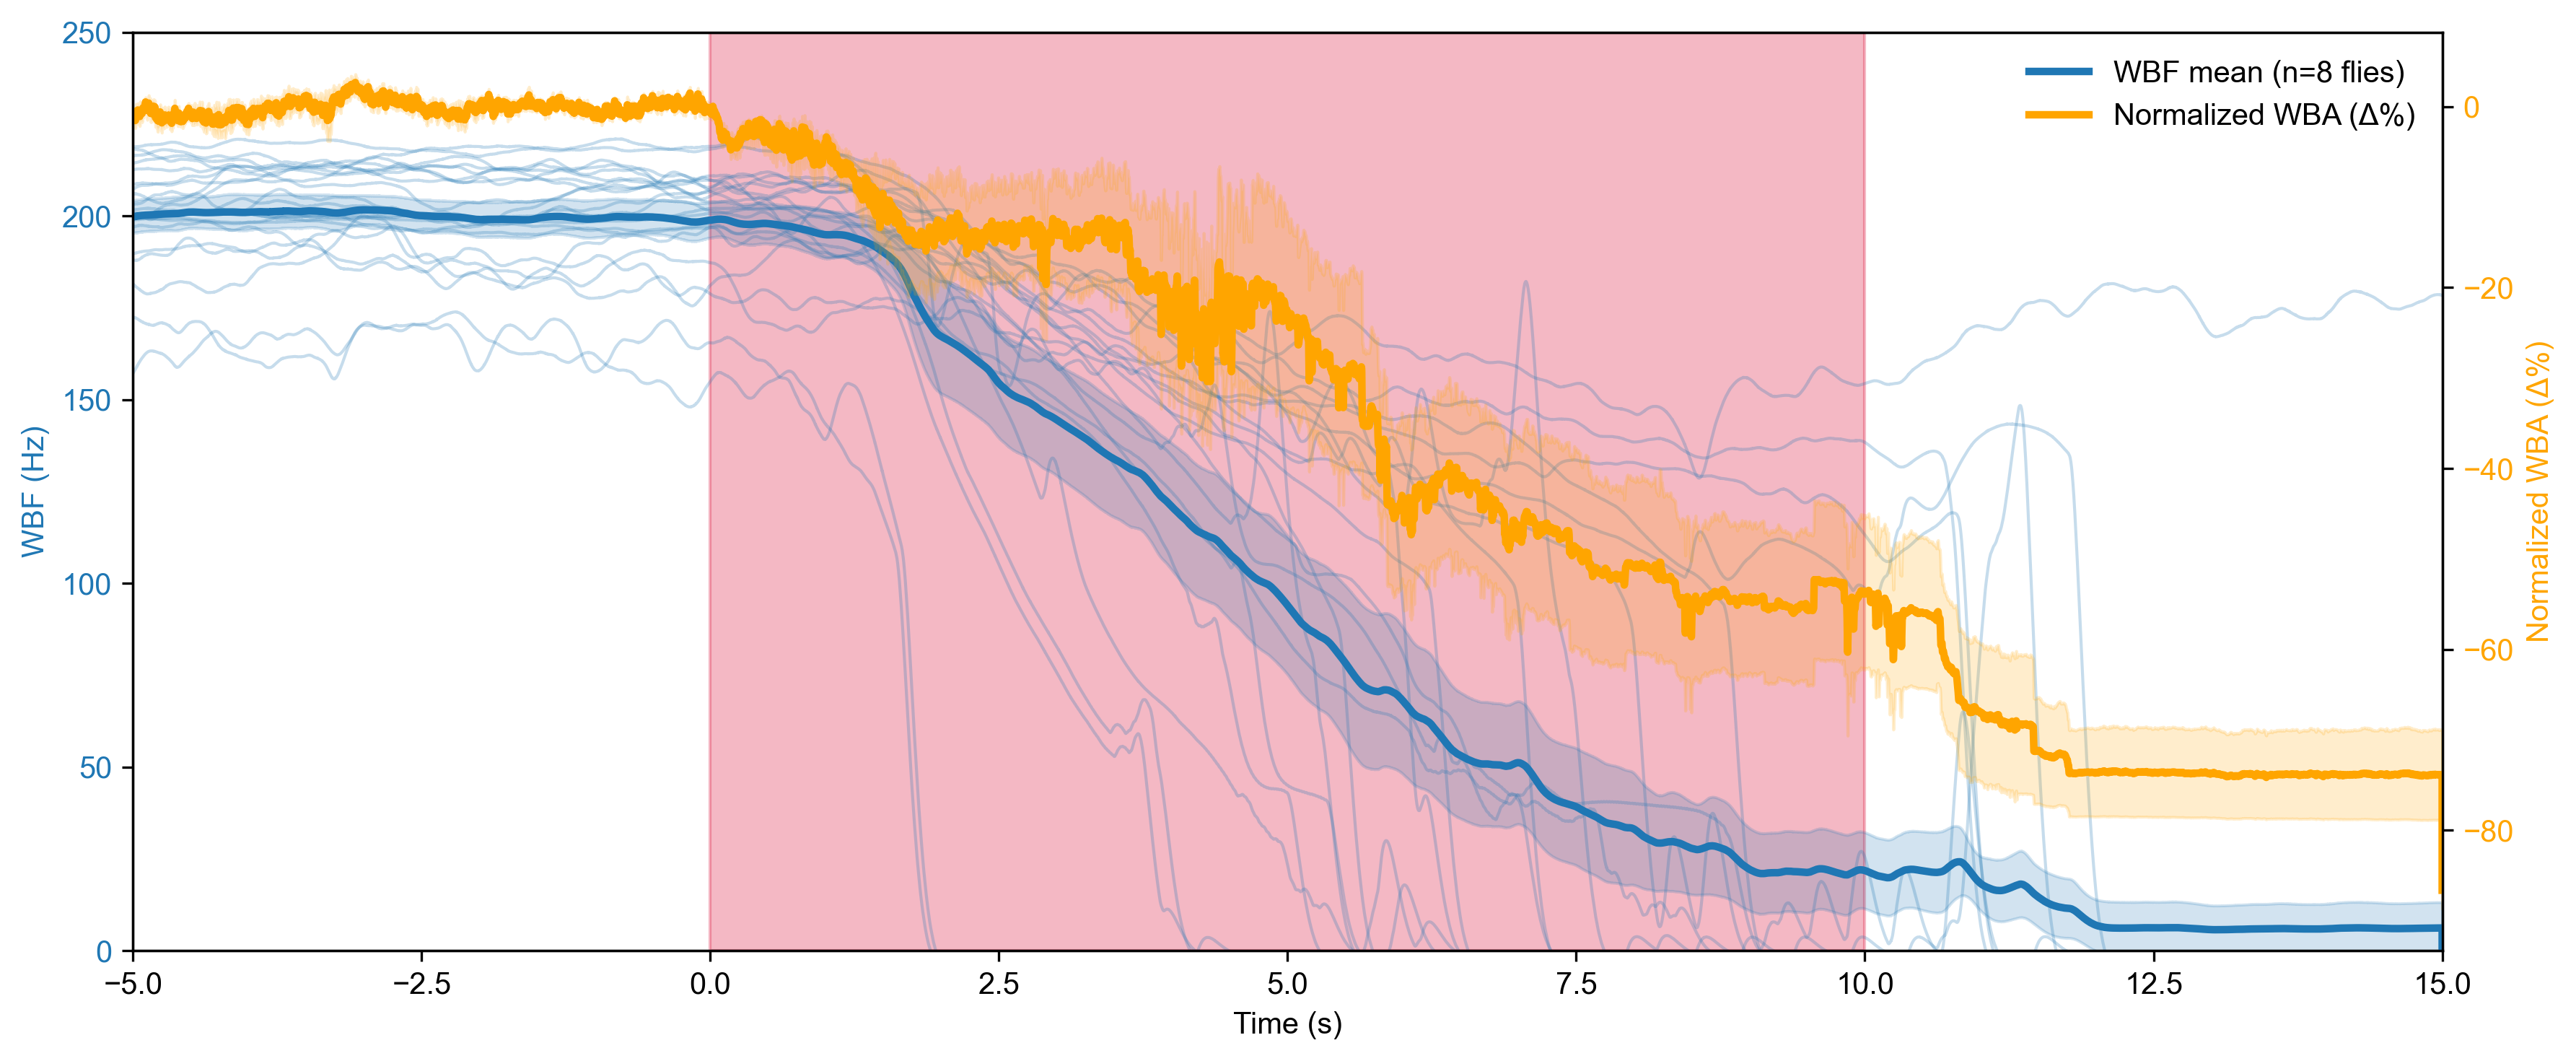

In [40]:
# ===== Cell 4: Plot SVG (Step4_no_EMG style) =====
stim_color = get_stim_color(INPUT_DIR)
print(f"Stim shading color: {stim_color}")

WBF_COLOR = '#1F77B4'

# Per-bout traces for overlay (re-read so we don't rely on Cell 3 in-memory state)
all_bout_wbf = []
for csv_path in sorted(glob.glob(os.path.join(BOUTS_DIR, "*.csv"))):
    df_b = pd.read_csv(csv_path)
    f = interpolate.interp1d(df_b['Time (s)'].values, df_b['Wingbeat Frequency'].values,
                             kind='linear', bounds_error=False, fill_value=np.nan)
    all_bout_wbf.append(f(CANONICAL_T))
print(f"Overlay: {len(all_bout_wbf)} individual bouts")

t = summary_df['Time (s)'].values
m_wbf = summary_df['Mean Wingbeat Frequency'].values
s_wbf = summary_df['SEM Wingbeat Frequency'].values
m_nwba = summary_df['Mean Normalized Wing Beat Amplitude'].values - 100
s_nwba = summary_df['SEM Normalized Wing Beat Amplitude'].values

fig, ax1 = plt.subplots(figsize=(12, 5), dpi=300)

# Individual per-bout traces (faint, behind mean)
for bout_trace in all_bout_wbf:
    ax1.plot(t, bout_trace, color=WBF_COLOR, alpha=0.25, linewidth=1, zorder=1)

# SEM fill + thick mean on top
ax1.fill_between(t, m_wbf - s_wbf, m_wbf + s_wbf, color=WBF_COLOR, alpha=0.2, zorder=2)
ax1.plot(t, m_wbf, color=WBF_COLOR, linewidth=2.5, label=f'WBF mean (n={n_flies} flies)', zorder=3)

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('WBF (Hz)', color=WBF_COLOR)
ax1.tick_params(axis='y', labelcolor=WBF_COLOR)
ax1.set_xlim(-5, STIM_DURATION_S + 5)

ax2 = ax1.twinx()
ax2.plot(t, m_nwba, color='orange', label='Normalized WBA (Δ%)', linewidth=2.5)
ax2.fill_between(t, m_nwba - s_nwba, m_nwba + s_nwba, color='orange', alpha=0.2)
ax2.set_ylabel('Normalized WBA (Δ%)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

ax1.set_ylim(0,250)
ymin, ymax = ax1.get_ylim()
ax1.fill_between([0, STIM_DURATION_S], ymin, ymax, color=stim_color, alpha=0.3, zorder=0)
ax1.set_ylim(ymin, ymax)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False)

out_svg = os.path.join(OUTPUT_DIR, f"summary_across_bouts_{stim_ms}ms.svg")
fig.tight_layout()
fig.savefig(out_svg, format='svg', bbox_inches='tight')
print(f"Wrote SVG: {out_svg}")
plt.show()
